<a href="https://colab.research.google.com/github/Neuraly4/cert-banana-coal/blob/main/cert-banana-coal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline Prediksi Risiko LTI (Lost Time Injury)
## PT. Banana Coal - Proyek Sertifikasi BNSP Associate Data Scientist

**Deskripsi Proyek:**
PT. Banana Coal adalah perusahaan pertambangan batubara di Kalimantan yang menghadapi
tekanan regulasi akibat meningkatnya angka insiden kerja. Notebook ini membangun pipeline
analisis data end-to-end untuk memprediksi risiko LTI (Lost Time Injury) menggunakan
dataset insiden SHE (Safety, Health, Environment) berisi 2.699 catatan periode 2022-2024.

**Target Variabel:** LTI (0 = tidak terjadi LTI, 1 = terjadi LTI)

**Struktur Pipeline:**
1. Modul 0: Setup dan Import Library
2. Modul 1: Pengumpulan Data dan Penentuan Objek Data
3. Modul 2: Telaah Data (Exploratory Data Analysis)
4. Modul 3: Validasi Data
5. Modul 4: Pembersihan Data (Data Cleaning)
6. Modul 5: Konstruksi Data (Feature Engineering)
7. Modul 6: Penentuan Label Data
8. Modul 7: Pembangunan Model Prediksi LTI
9. Modul 8: Evaluasi Hasil Pemodelan
10. Modul 9: Penyimpanan Artefak

---
# Modul 0: Setup dan Import Library
Instalasi dependensi dan import seluruh library yang dibutuhkan untuk pipeline.

In [1]:
# -- Instalasi library yang mungkin belum tersedia di environment --
# gdown: untuk download dataset dari Google Drive
# xgboost: untuk algoritma gradient boosting
# imbalanced-learn: untuk penanganan class imbalance (SMOTE)
!pip install -q gdown xgboost imbalanced-learn openpyxl

In [3]:
# -- Import library utama --
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
import pickle
from datetime import datetime
import gdown

# -- Library Machine Learning --
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, GridSearchCV)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_curve, auc
)
from imblearn.over_sampling import SMOTE
import xgboost as xgb

# -- Konfigurasi --
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.rcParams.update({
    'figure.figsize': (12, 6), 'font.size': 11,
    'axes.titlesize': 14, 'axes.labelsize': 12,
    'figure.dpi': 100
})
sns.set_style('whitegrid')
sns.set_palette('muted')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Semua library berhasil diimport.')

Semua library berhasil diimport.


---
# Modul 1: Pengumpulan Data dan Penentuan Objek Data

**Tujuan Analisis:** Membangun model prediksi risiko LTI berbasis machine learning
untuk membantu manajemen PT. Banana Coal mengambil keputusan strategis pencegahan kecelakaan kerja.

**Unit Analisis:** Setiap baris = 1 kejadian insiden SHE.
**Periode Data:** Januari 2022 - Desember 2024
**Sumber Data:** Dataset_SHE_PTBananaCoal.xlsx (sheet: Log_Insiden_SHE, 2.699 baris x 26 kolom)

In [5]:
# Nama file
file_name = "Dataset.csv"

# Cek apakah file sudah ada
if not os.path.exists(file_name):
    gdown.download(
        "https://drive.google.com/uc?id=1IyMMGTzHVuOC4VIFowaiUH4gOPJlL5-4",
        file_name,
        quiet=False
    )

# Load dataset ke dataframe
df = pd.read_csv(file_name)

# Tampilkan info dataset
print(f'Dataset berhasil dimuat: {df.shape[0]} baris x {df.shape[1]} kolom')

Dataset berhasil dimuat: 2699 baris x 26 kolom


In [6]:
# -- Inspeksi awal: 5 baris pertama --
print('=== 5 Baris Pertama Dataset ===')
df.head()

=== 5 Baris Pertama Dataset ===


,No,Tanggal,Hari,Bulan,Kuartal,Tahun,Shift,Area_Kerja,Supervisor_ID,Jenis_Pekerjaan,Jenis_Insiden,Near_Miss,First_Aid,Medical_Treatment,LTI,Fatality,Hari_Hilang_Kerja,Property_Damage,Jumlah_Tenaga_Kerja,Jam_Kerja,Kondisi_Cuaca,Penyebab_Utama,Tindakan_Korektif,Status_Tindakan,Lokasi_Spesifik,Catatan
0,1,2023-06-26,Monday,6,Q2,2023,Shift 1 (07:00-19:00),Drainase,SPV-009,Grading,Near Miss,1,0,0,0,0,0,0,29,298.20,Cerah,Komunikasi Buruk,Revisi Prosedur,Belum Dimulai,Draina-Blok02,NaN
1,2,2023-05-10,Wednesday,5,Q2,2023,Shift 2 (19:00-07:00),Drainase,SPV-010,Dozing,First Aid,0,1,0,0,0,0,0,10,105.40,Cerah,Alat Pelindung Diri Tidak Sesuai,Pelatihan Ulang,Dalam Proses,Draina-Blok05,NaN
2,3,2023-03-27,Monday,3,Q1,2023,Shift 2 (19:00-07:00),ROM (Run of Mine),SPV-011,Administrasi,Near Miss,1,0,0,0,0,0,0,35,393.70,Cerah,Desain/Engineering,Investigasi Lanjut,Selesai,ROM (R-Blok02,NaN
3,4,2022-11-29,Tuesday,11,Q4,2022,Shift 2 (19:00-07:00),Pit-C (Hauling),SPV-020,Loading,Medical Treatment,0,0,1,0,0,0,0,22,258.00,Cerah,Human Error,Revisi Prosedur,Selesai,Pit-C-Blok02,NaN
4,5,2023-05-13,Saturday,5,Q2,2023,Shift 2 (19:00-07:00),Pit-B (Coal Getting),SPV-018,Survei,First Aid,0,1,0,0,0,0,0,40,459.60,Berkabut,Komunikasi Buruk,Investigasi Lanjut,Selesai,Pit-B-Blok04,Menunggu spare part


In [7]:
# -- Informasi tipe data dan non-null count --
print('=== Informasi Dataset ===')
df.info()

=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2699 entries, 0 to 2698
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   No                   2699 non-null   int64  
 1   Tanggal              2697 non-null   object 
 2   Hari                 2699 non-null   object 
 3   Bulan                2699 non-null   int64  
 4   Kuartal              2699 non-null   object 
 5   Tahun                2699 non-null   int64  
 6   Shift                2699 non-null   object 
 7   Area_Kerja           2683 non-null   object 
 8   Supervisor_ID        2688 non-null   object 
 9   Jenis_Pekerjaan      2692 non-null   object 
 10  Jenis_Insiden        2698 non-null   object 
 11  Near_Miss            2699 non-null   int64  
 12  First_Aid            2699 non-null   int64  
 13  Medical_Treatment    2699 non-null   int64  
 14  LTI                  2699 non-null   int64  
 15  Fatality    

In [8]:
# -- Daftar semua kolom beserta tipe dan kelengkapan data --
print('=== Daftar Kolom ===')
for i, (col, dtype) in enumerate(zip(df.columns, df.dtypes), 1):
    print(f'{i:2d}. {col:<30s} | Tipe: {str(dtype):<15s} | Non-null: {df[col].notna().sum()}/{len(df)}')

=== Daftar Kolom ===
 1. No                             | Tipe: int64           | Non-null: 2699/2699
 2. Tanggal                        | Tipe: object          | Non-null: 2697/2699
 3. Hari                           | Tipe: object          | Non-null: 2699/2699
 4. Bulan                          | Tipe: int64           | Non-null: 2699/2699
 5. Kuartal                        | Tipe: object          | Non-null: 2699/2699
 6. Tahun                          | Tipe: int64           | Non-null: 2699/2699
 7. Shift                          | Tipe: object          | Non-null: 2699/2699
 8. Area_Kerja                     | Tipe: object          | Non-null: 2683/2699
 9. Supervisor_ID                  | Tipe: object          | Non-null: 2688/2699
10. Jenis_Pekerjaan                | Tipe: object          | Non-null: 2692/2699
11. Jenis_Insiden                  | Tipe: object          | Non-null: 2698/2699
12. Near_Miss                      | Tipe: int64           | Non-null: 2699/2699
13. Fir

In [9]:
# -- Statistik deskriptif numerik --
print('=== Statistik Deskriptif (Numerik) ===')
df.describe()

=== Statistik Deskriptif (Numerik) ===


,No,Bulan,Tahun,Near_Miss,First_Aid,Medical_Treatment,LTI,Fatality,Hari_Hilang_Kerja,Property_Damage,Jumlah_Tenaga_Kerja,Jam_Kerja
count,2699.00,2699.00,2699.00,2699.00,2699.00,2699.00,2699.00,2699.00,2699.00,2699.00,2699.00,2699.00
mean,1350.00,6.47,2023.01,0.42,0.26,0.18,0.08,0.00,0.59,0.05,26.70,321.35
std,779.28,3.40,0.82,0.49,0.44,0.38,0.27,0.04,2.35,0.22,11.04,310.58
min,1.00,1.00,2022.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-100.00
25%,675.50,4.00,2022.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,17.00,192.50
50%,1350.00,6.00,2023.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,27.00,307.10
75%,2024.50,9.00,2024.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,36.00,413.80
max,2699.00,12.00,2024.00,1.00,1.00,1.00,1.00,1.00,14.00,1.00,45.00,9999.00


In [10]:
# -- Statistik deskriptif kategorik --
print('=== Statistik Deskriptif (Kategorik) ===')
df.describe(include='object')

=== Statistik Deskriptif (Kategorik) ===


,Tanggal,Hari,Kuartal,Shift,Area_Kerja,Supervisor_ID,Jenis_Pekerjaan,Jenis_Insiden,Kondisi_Cuaca,Penyebab_Utama,Tindakan_Korektif,Status_Tindakan,Lokasi_Spesifik,Catatan
count,2697,2699,2699,2699,2683,2688,2692,2698,2688,2691,2699,2699,2699,1364
unique,1098,7,4,7,17,20,12,6,5,10,7,4,40,4
top,2024-01-11,Friday,Q3,Shift 1 (07:00-19:00),Pit-B (Coal Getting),SPV-003,Loading,Near Miss,Cerah,Peralatan Rusak,Penggantian APD,Selesai,Pit-B-Blok02,Perlu tindak lanjut
freq,6,403,697,1402,561,159,249,1124,1066,298,412,1504,127,354


### Data Dictionary

| No | Kolom | Deskripsi | Tipe |
|:---|:------|:----------|:-----|
| 1 | Supervisor_ID | Kode identitas pengawas | Kategorik |
| 2 | Jenis_Pekerjaan | Aktivitas saat insiden (Hauling, Drilling, Blasting, dll.) | Kategorik |
| 3 | Jumlah_Tenaga_Kerja | Jumlah pekerja di area saat kejadian | Numerik |
| 4 | Jam_Kerja | Total jam kerja kumulatif tim pada sesi | Numerik |
| 5 | Jenis_Insiden | Kategori utama insiden | Kategorik |
| 6 | Near_Miss | Kejadian hampir celaka (0/1) | Biner |
| 7 | First_Aid | Pertolongan pertama ringan (0/1) | Biner |
| 8 | Medical_Treatment | Penanganan medis lanjut (0/1) | Biner |
| 9 | LTI | Lost Time Injury - tidak masuk >= 1 hari (0/1) | Biner (TARGET) |
| 10 | Fatality | Mengakibatkan kematian (0/1) | Biner |
| 11 | Hari_Hilang_Kerja | Jumlah hari kerja hilang (hanya jika LTI=1) | Numerik |
| 12 | Property_Damage | Kerusakan aset/peralatan (0/1) | Biner |
| 13 | Kondisi_Cuaca | Kondisi cuaca saat insiden | Kategorik |
| 14 | Penyebab_Utama | Akar penyebab insiden | Kategorik |
| 15 | Tindakan_Korektif | Langkah perbaikan yang direkomendasikan | Kategorik |
| 16 | Status_Tindakan | Progres tindakan korektif | Kategorik |
| 17 | Catatan | Keterangan tambahan (opsional) | Teks |
| 18 | Shift | Shift kerja saat insiden | Kategorik |
| 19 | Area_Kerja | Lokasi area kerja insiden | Kategorik |
| 20 | Tanggal | Tanggal kejadian insiden | Datetime |

### Summary Modul 1: Pengumpulan Data
- Dataset berhasil dimuat dari sumber yang tersedia (lokal atau Google Drive)
- Periksa apakah jumlah baris dan kolom sesuai spesifikasi (2.699 x 26)
- Identifikasi tipe data awal untuk perencanaan pembersihan
- Kolom target (LTI) teridentifikasi sebagai variabel biner

---
# Modul 2: Telaah Data (Exploratory Data Analysis)

Tahap EDA untuk memahami karakteristik, distribusi, dan pola dalam dataset
sebelum pembersihan dan pemodelan.

## 2.1 Statistik Deskriptif Variabel Numerik

In [11]:
# -- Statistik deskriptif mendetail untuk variabel numerik kunci --
kolom_numerik = ['Jam_Kerja', 'Jumlah_Tenaga_Kerja', 'Hari_Hilang_Kerja']
kolom_numerik_ada = [c for c in kolom_numerik if c in df.columns]

if kolom_numerik_ada:
    stats = df[kolom_numerik_ada].describe().T
    stats['median'] = df[kolom_numerik_ada].median()
    stats['skewness'] = df[kolom_numerik_ada].skew()
    stats['kurtosis'] = df[kolom_numerik_ada].kurtosis()
    stats['missing'] = df[kolom_numerik_ada].isnull().sum()
    stats['missing_pct'] = (df[kolom_numerik_ada].isnull().sum() / len(df) * 100).round(2)
    print('=== Statistik Deskriptif Variabel Numerik ===')
    display(stats)
else:
    print('Kolom numerik tidak ditemukan. Kolom tersedia:', df.columns.tolist())

=== Statistik Deskriptif Variabel Numerik ===


,count,mean,std,min,25%,50%,75%,max,median,skewness,kurtosis,missing,missing_pct
Jam_Kerja,2699.00,321.35,310.58,-100.00,192.50,307.10,413.80,9999.00,307.10,16.79,417.81,0,0.00
Jumlah_Tenaga_Kerja,2699.00,26.70,11.04,0.00,17.00,27.00,36.00,45.00,27.00,-0.03,-1.20,0,0.00
Hari_Hilang_Kerja,2699.00,0.59,2.35,0.00,0.00,0.00,0.00,14.00,0.00,4.18,16.84,0,0.00


### Insight 2.1 – Statistik Deskriptif Variabel Numerik

#### Poin-poin Utama

- **Jam_Kerja**
  - Terdapat nilai minimum negatif (-100) yang tidak valid.
  - Nilai maksimum sangat ekstrem (9999), menunjukkan adanya outlier.
  - Distribusi sangat miring ke kanan (skewness tinggi: 16.79).
  - Kurtosis sangat tinggi (417.81), menandakan banyak outlier ekstrem.
  - Mean (321.35) lebih besar dari median (307.10), mengindikasikan pengaruh outlier.

- **Jumlah_Tenaga_Kerja**
  - Rentang nilai wajar (0–45).
  - Distribusi relatif simetris (skewness mendekati 0).
  - Mean (26.70) hampir sama dengan median (27.00).
  - Tidak terdapat indikasi outlier ekstrem atau anomali signifikan.

- **Hari_Hilang_Kerja**
  - Mayoritas nilai adalah 0 (Q1, median, dan Q3 = 0).
  - Distribusi sangat miring ke kanan (skewness 4.18).
  - Kurtosis tinggi (16.84), menunjukkan adanya nilai ekstrem meskipun jarang.
  - Nilai maksimum 14, menunjukkan hanya sebagian kecil kasus dengan hari hilang kerja tinggi.

- **Missing Values**
  - Tidak terdapat missing values pada seluruh variabel (0%).


## 2.2 Distribusi Frekuensi Variabel Kategorik

In [12]:
# -- Distribusi frekuensi variabel kategorik utama --
kolom_kategorik = ['Shift', 'Area_Kerja', 'Jenis_Insiden', 'Penyebab_Utama',
                   'Kondisi_Cuaca', 'Jenis_Pekerjaan', 'Status_Tindakan']
kolom_kategorik_ada = [c for c in kolom_kategorik if c in df.columns]

for col in kolom_kategorik_ada:
    print(f'\n=== Distribusi {col} ===')
    freq = df[col].value_counts()
    pct = df[col].value_counts(normalize=True) * 100
    tabel = pd.DataFrame({'Frekuensi': freq, 'Persentase (%)': pct.round(2)})
    display(tabel)
    print(f'Jumlah kategori unik: {df[col].nunique()}')
    print('-' * 50)


=== Distribusi Shift ===


,Frekuensi,Persentase (%)
Shift,,
Shift 1 (07:00-19:00),1402,51.95
Shift 2 (19:00-07:00),1287,47.68
S2,3,0.11
Malam,3,0.11
SHIFT 1,2,0.07
Shift-2,1,0.04
shift1,1,0.04


Jumlah kategori unik: 7
--------------------------------------------------

=== Distribusi Area_Kerja ===


,Frekuensi,Persentase (%)
Area_Kerja,,
Pit-B (Coal Getting),561,20.91
Pit-C (Hauling),463,17.26
Pit-A (Overburden),457,17.03
Workshop,306,11.41
ROM (Run of Mine),290,10.81
Drainase,204,7.60
Stockpile,204,7.60
Office Area,178,6.63
wrkshop,6,0.22


Jumlah kategori unik: 17
--------------------------------------------------

=== Distribusi Jenis_Insiden ===


...

Jumlah kategori unik: 5
--------------------------------------------------

=== Distribusi Jenis_Pekerjaan ===


,Frekuensi,Persentase (%)
Jenis_Pekerjaan,,
Loading,249,9.25
Fueling,243,9.03
Survei,239,8.88
Maintenance,237,8.80
Blasting,234,8.69
Dozing,230,8.54
Pengawasan,226,8.40
Grading,215,7.99
Administrasi,212,7.88


Jumlah kategori unik: 12
--------------------------------------------------

=== Distribusi Status_Tindakan ===


,Frekuensi,Persentase (%)
Status_Tindakan,,
Selesai,1504,55.72
Dalam Proses,655,24.27
Belum Dimulai,328,12.15
Overdue,212,7.85


Jumlah kategori unik: 4
--------------------------------------------------


### Insight 2.2 - Distribusi Frekuensi

**Poin-Poin Insight:**
- Terdapat indikasi inkonsistensi penulisan pada variabel kategorikal seperti `Shift` dan `Area_Kerja`, yang berpotensi menyebabkan duplikasi kategori (misalnya perbedaan huruf besar/kecil atau spasi).
- Distribusi jenis insiden kemungkinan tidak seimbang, dengan dominasi pada kategori insiden ringan seperti *Near Miss* dan *First Aid*, sementara *Medical Treatment* dan *LTI* cenderung lebih sedikit.
- Penyebab insiden tertentu muncul lebih dominan dibandingkan yang lain, menunjukkan adanya pola risiko yang berulang dalam operasional.
- Status tindakan korektif menunjukkan masih adanya kasus dengan status *Overdue* atau *Belum Dimulai*, yang mengindikasikan potensi kelemahan dalam tindak lanjut perbaikan.

## 2.3 Visualisasi: Tren Insiden per Tahun dan Kuartal

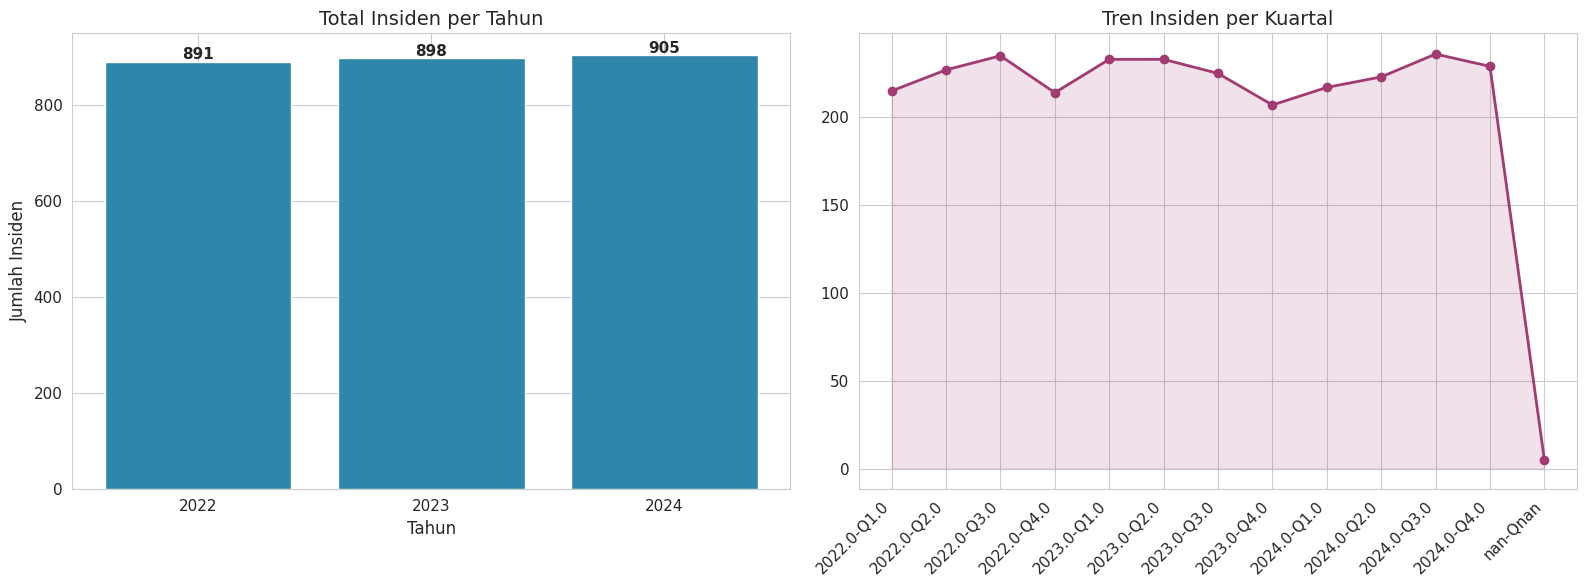

In [13]:
# -- Visualisasi 1: Tren insiden per tahun dan kuartal --
if 'Tanggal' in df.columns:
    df['_Tanggal'] = pd.to_datetime(df['Tanggal'], errors='coerce')
    df['_Tahun'] = df['_Tanggal'].dt.year
    df['_Kuartal'] = df['_Tanggal'].dt.quarter
    df['_TK'] = df['_Tahun'].astype(str) + '-Q' + df['_Kuartal'].astype(str)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Tren per tahun
    tren = df.groupby('_Tahun').size()
    axes[0].bar(tren.index.astype(int), tren.values, color='#2E86AB', edgecolor='white')
    axes[0].set_title('Total Insiden per Tahun')
    axes[0].set_xlabel('Tahun'); axes[0].set_ylabel('Jumlah Insiden')
    axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    for i, v in enumerate(tren.values):
        axes[0].text(tren.index[i], v + 5, str(v), ha='center', fontweight='bold')

    # Tren per kuartal
    tren_q = df.groupby('_TK').size()
    axes[1].plot(range(len(tren_q)), tren_q.values, marker='o', color='#A23B72', linewidth=2)
    axes[1].set_xticks(range(len(tren_q)))
    axes[1].set_xticklabels(tren_q.index, rotation=45, ha='right')
    axes[1].set_title('Tren Insiden per Kuartal')
    axes[1].fill_between(range(len(tren_q)), tren_q.values, alpha=0.15, color='#A23B72')

    plt.tight_layout(); plt.show()
    df.drop(columns=['_Tanggal', '_Tahun', '_Kuartal', '_TK'], inplace=True)

### Poin-Poin Insight:
- Jumlah insiden tahunan terlihat sangat stabil dari 2022 hingga 2024, yang menandakan bahwa risiko atau masalah yang memicu insiden berada pada tingkat yang terkendali namun tetap konsisten.
- Terdapat pola fluktuasi kuartalan yang berulang setiap tahunnya, menunjukkan bahwa karakteristik kejadian cenderung dapat diprediksi berdasarkan pola musiman.
- Ditemukan anomali berupa data "nan-Qnan" pada grafik kuartalan yang mengindikasikan adanya catatan insiden dengan tanggal yang tidak lengkap atau kesalahan sistem saat proses ekstraksi data.


Sebagai langkah selanjutnya, sangat disarankan untuk segera melakukan audit kualitas data pada entri yang tidak memiliki keterangan waktu tersebut. Selain itu, karena tren insiden yang sangat mendatar, strategi manajemen risiko saat ini perlu ditinjau ulang agar tidak sekadar bertahan di angka yang sama, tetapi mulai berupaya untuk menurunkan frekuensi insiden secara bertahap.

## 2.4 Visualisasi: Komposisi Insiden per Area Kerja

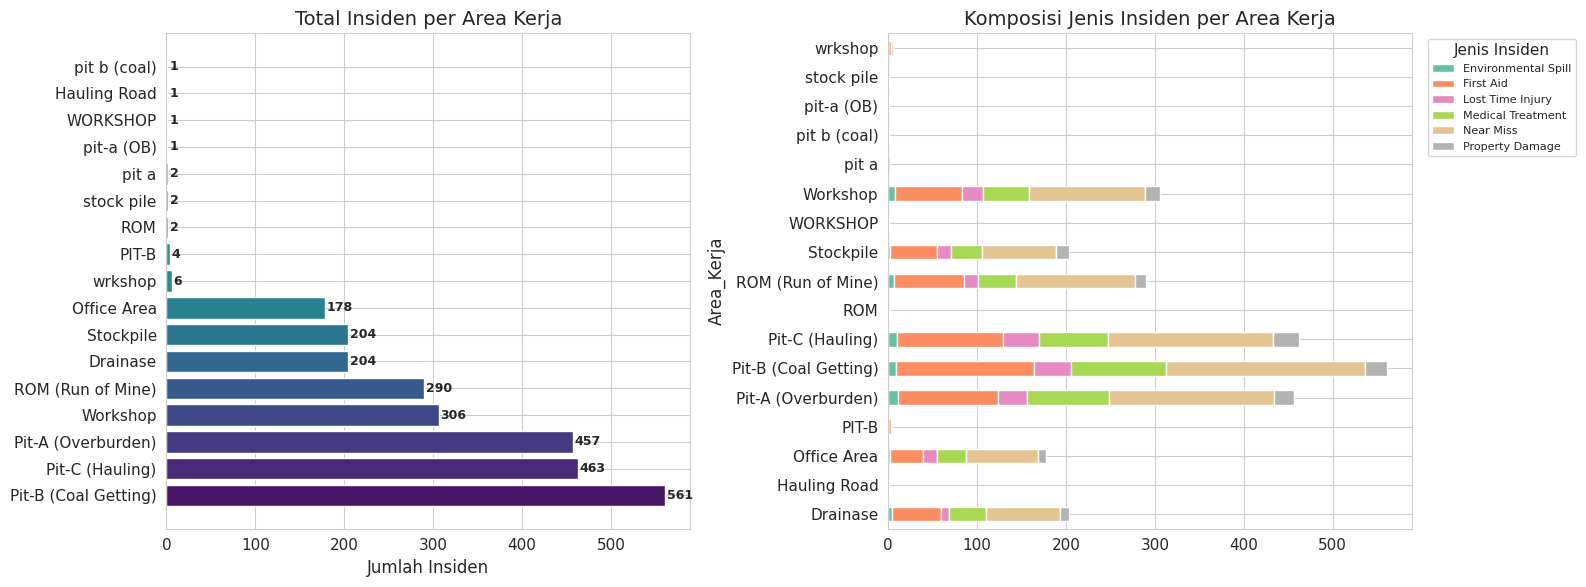

In [14]:
# -- Visualisasi 2: Komposisi insiden per area kerja --
if 'Area_Kerja' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    area_count = df['Area_Kerja'].value_counts()
    colors = sns.color_palette('viridis', len(area_count))
    axes[0].barh(area_count.index, area_count.values, color=colors, edgecolor='white')
    axes[0].set_title('Total Insiden per Area Kerja')
    axes[0].set_xlabel('Jumlah Insiden')
    for i, v in enumerate(area_count.values):
        axes[0].text(v + 2, i, str(v), va='center', fontweight='bold', fontsize=9)

    if 'Jenis_Insiden' in df.columns:
        cross = pd.crosstab(df['Area_Kerja'], df['Jenis_Insiden'])
        cross.plot(kind='barh', stacked=True, ax=axes[1], colormap='Set2', edgecolor='white')
        axes[1].set_title('Komposisi Jenis Insiden per Area Kerja')
        axes[1].legend(title='Jenis Insiden', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

    plt.tight_layout(); plt.show()

### Insight 2.4 - Area Kerja
### Poin-Poin Insight:
- Area operasional utama, khususnya Pit-B (Coal Getting), Pit-C (Hauling), dan Pit-A (Overburden), merupakan kontributor insiden tertinggi dengan selisih yang signifikan dibandingkan area lainnya.
- Ditemukan inkonsistensi penamaan data seperti "Workshop" vs "WORKSHOP" dan "pit-a (OB)" vs "Pit-A (Overburden)", yang menyebabkan duplikasi entri dan penurunan akurasi pada klasifikasi area.
- Kategori "Near Miss" mendominasi komposisi jenis insiden di hampir seluruh area kerja dengan volume tinggi, diikuti oleh "First Aid".
- Pit-B (Coal Getting), Pit-C (Hauling), dan Pit-A (Overburden) mencatat frekuensi "Lost Time Injury" (LTI) tertinggi, yang menandai area tersebut sebagai lokasi dengan tingkat risiko keselamatan paling kritis.

## 2.5 Visualisasi: Heatmap Insiden per Hari dan Shift

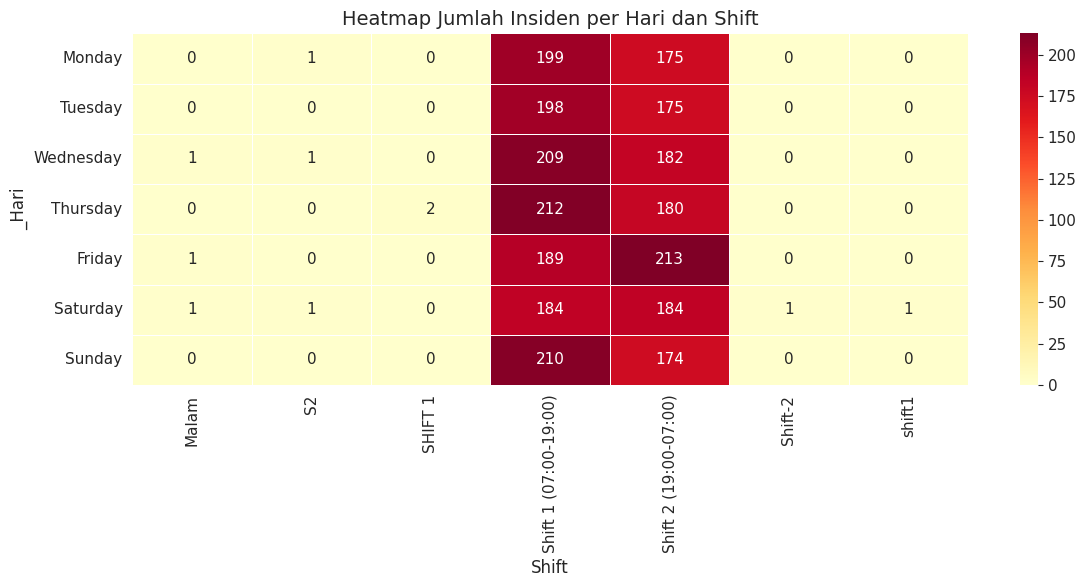

In [15]:
# -- Visualisasi 3: Heatmap insiden per hari dan shift --
if 'Tanggal' in df.columns and 'Shift' in df.columns:
    df['_Tanggal'] = pd.to_datetime(df['Tanggal'], errors='coerce')
    df['_Hari'] = df['_Tanggal'].dt.day_name()

    urutan_hari = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
    hari_ada = [h for h in urutan_hari if h in df['_Hari'].values]

    heatmap_data = pd.crosstab(df['_Hari'], df['Shift']).reindex(hari_ada)

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd',
                linewidths=0.5, linecolor='white', ax=ax)
    ax.set_title('Heatmap Jumlah Insiden per Hari dan Shift')
    plt.tight_layout(); plt.show()
    df.drop(columns=['_Tanggal', '_Hari'], inplace=True)

### Insight 2.5 - Heatmap Hari/Shift
### Poin-Poin Insight:
- Terjadi konsentrasi insiden yang sangat dominan pada dua kategori shift utama, yaitu "Shift 1 (07:00-19:00)" dan "Shift 2 (19:00-07:00)", sementara kategori shift lainnya hampir tidak mencatat insiden sama sekali.
- Distribusi insiden terlihat cukup merata sepanjang hari dalam seminggu pada kedua shift utama tersebut, yang menandakan bahwa risiko tidak bergantung pada hari tertentu, melainkan pada durasi operasional shift.
- Terdapat indikasi masalah inkonsistensi input data pada kolom Shift, di mana terdapat banyak variasi penamaan (Malam, S2, SHIFT 1, Shift-2, shift1) yang memiliki jumlah insiden sangat minim, sehingga mengaburkan data operasional yang sebenarnya.
- Perbandingan antara shift siang dan malam tidak menunjukkan perbedaan yang ekstrem, dengan tingkat kejadian yang tinggi dan relatif seimbang di kedua shift utama, yang mengindikasikan bahwa risiko operasional tetap tinggi sepanjang waktu tanpa melihat siklus siang atau malam.

## 2.6 Visualisasi: Distribusi Penyebab Utama

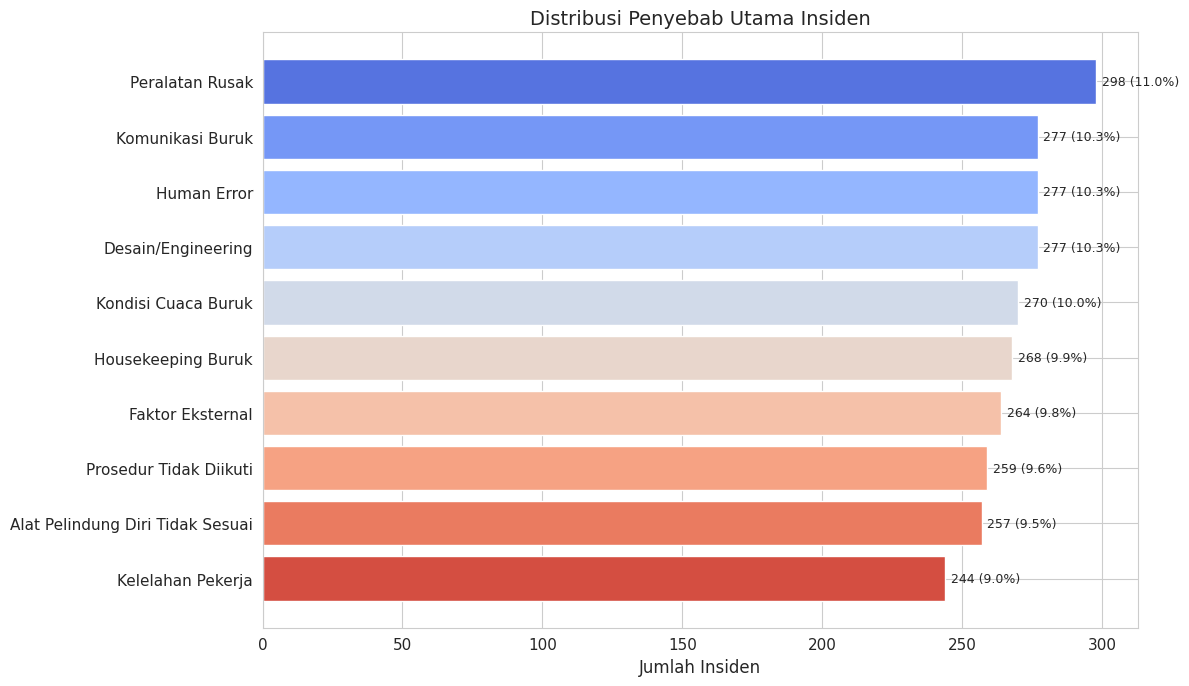

In [16]:
# -- Visualisasi 4: Penyebab utama insiden --
if 'Penyebab_Utama' in df.columns:
    fig, ax = plt.subplots(figsize=(12, 7))
    penyebab_count = df['Penyebab_Utama'].value_counts()
    colors = sns.color_palette('coolwarm', len(penyebab_count))
    bars = ax.barh(penyebab_count.index, penyebab_count.values, color=colors, edgecolor='white')
    ax.set_title('Distribusi Penyebab Utama Insiden')
    ax.set_xlabel('Jumlah Insiden')
    ax.invert_yaxis()
    for bar, val in zip(bars, penyebab_count.values):
        ax.text(val + 2, bar.get_y() + bar.get_height()/2,
                f'{val} ({val/len(df)*100:.1f}%)', va='center', fontsize=9)
    plt.tight_layout(); plt.show()

### Insight 2.6 - Penyebab Utama
### Poin-Poin Insight:
- Tiga penyebab insiden paling dominan adalah Peralatan Rusak (11,0%), diikuti oleh Komunikasi Buruk (10,3%), dan Human Error (10,3%), yang secara kolektif mencakup hampir sepertiga dari total kejadian.
- Distribusi penyebab insiden sangat merata di seluruh kategori, dengan selisih yang tipis antara peringkat pertama (11,0%) hingga peringkat terakhir (9,0%), yang menunjukkan bahwa risiko bersifat multifaktorial dan tidak didominasi oleh satu faktor tunggal.
- Human Error tidak menjadi faktor tunggal yang dominan; proporsinya setara dengan faktor teknis seperti Komunikasi Buruk dan Desain/Engineering, yang menyiratkan perlunya pendekatan perbaikan sistemik alih-alih hanya berfokus pada individu.
- Sebagian besar penyebab insiden bersifat preventif melalui intervensi manajemen, seperti perbaikan pemeliharaan peralatan, peninjauan prosedur operasional, dan peningkatan standar penggunaan APD, yang secara total menyumbang proporsi yang cukup signifikan dari keseluruhan data.

## 2.7 Visualisasi: Distribusi Jenis Insiden

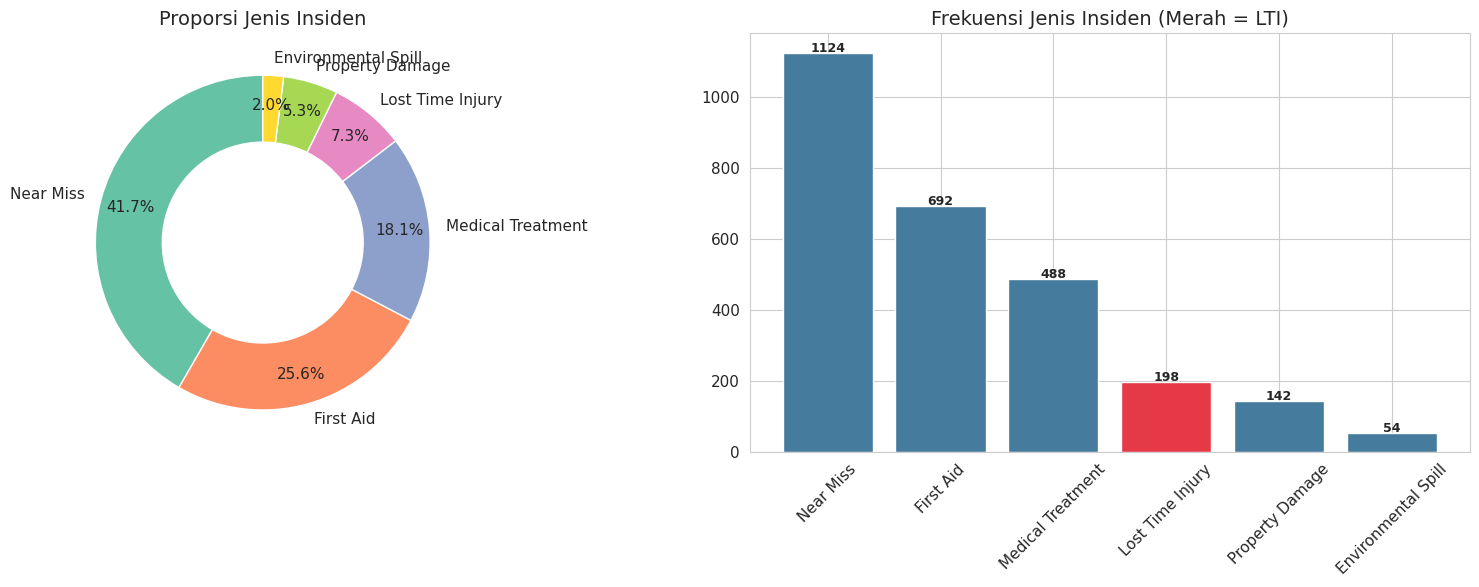

In [17]:
# -- Visualisasi 5: Distribusi jenis insiden --
if 'Jenis_Insiden' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    jenis_count = df['Jenis_Insiden'].value_counts()
    colors_d = sns.color_palette('Set2', len(jenis_count))
    axes[0].pie(jenis_count.values, labels=jenis_count.index, autopct='%1.1f%%',
                startangle=90, colors=colors_d, pctdistance=0.82,
                wedgeprops=dict(width=0.4, edgecolor='white'))
    axes[0].set_title('Proporsi Jenis Insiden')

    bar_colors = ['#E63946' if 'LTI' in idx or 'Lost' in idx else '#457B9D'
                  for idx in jenis_count.index]
    axes[1].bar(jenis_count.index, jenis_count.values, color=bar_colors, edgecolor='white')
    axes[1].set_title('Frekuensi Jenis Insiden (Merah = LTI)')
    axes[1].tick_params(axis='x', rotation=45)
    for i, v in enumerate(jenis_count.values):
        axes[1].text(i, v + 3, str(v), ha='center', fontweight='bold', fontsize=9)

    plt.tight_layout(); plt.show()

### Insight 2.7 - Jenis Insiden
- Near Miss mendominasi dengan proporsi sebesar 41,7% dari total seluruh insiden, yang menunjukkan bahwa sistem pelaporan insiden dini berjalan cukup aktif di lapangan.
- Insiden dengan tingkat keparahan yang lebih tinggi, yaitu Lost Time Injury (LTI), mencakup 7,3% dari total keseluruhan kejadian.
- Jika digabungkan, Near Miss dan First Aid menyumbang lebih dari 67% dari total data, yang secara umum selaras dengan prinsip dasar piramida keselamatan (bahwa kejadian berisiko rendah harus jauh lebih tinggi daripada kejadian fatal).
- Medical Treatment dan LTI secara akumulatif mencapai lebih dari 25% dari total insiden, angka yang cukup signifikan dan memerlukan perhatian khusus karena melibatkan intervensi medis serta kehilangan waktu kerja.

## 2.8 Visualisasi: Boxplot Variabel Numerik

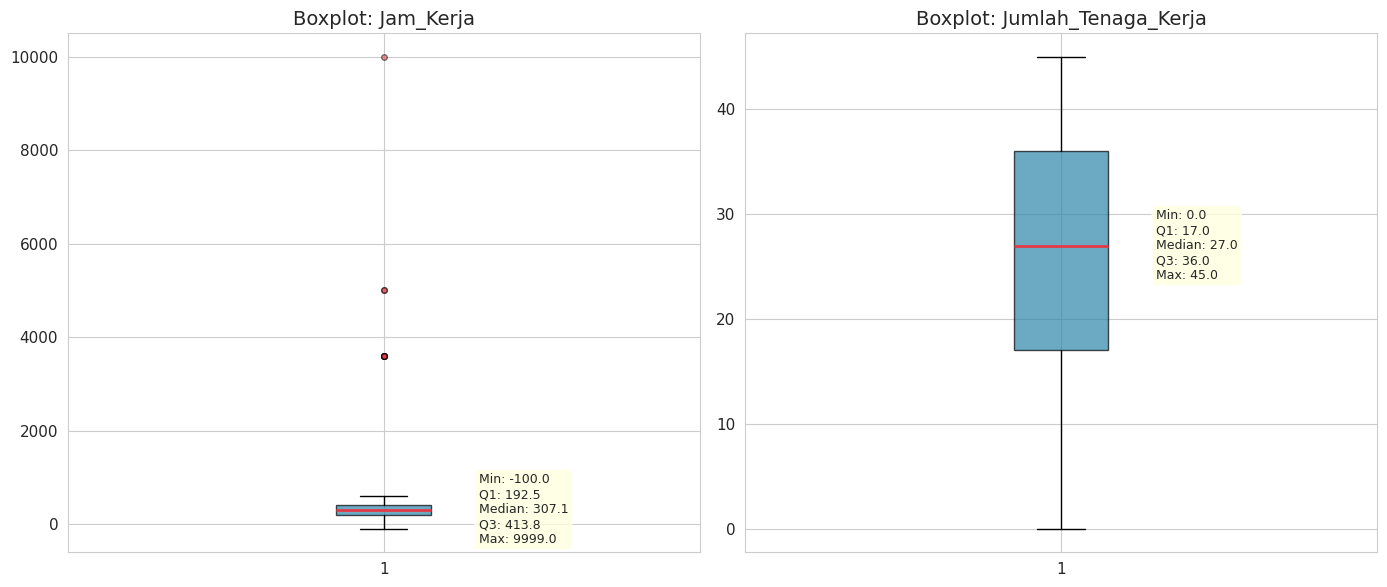

In [18]:
# -- Visualisasi 6: Boxplot untuk deteksi outlier --
kolom_bp = [c for c in ['Jam_Kerja', 'Jumlah_Tenaga_Kerja'] if c in df.columns]
if kolom_bp:
    fig, axes = plt.subplots(1, len(kolom_bp), figsize=(7*len(kolom_bp), 6))
    if len(kolom_bp) == 1: axes = [axes]
    for ax, col in zip(axes, kolom_bp):
        ax.boxplot(df[col].dropna(), patch_artist=True,
                   boxprops=dict(facecolor='#2E86AB', alpha=0.7),
                   medianprops=dict(color='#E63946', linewidth=2),
                   flierprops=dict(marker='o', markerfacecolor='#E63946', markersize=4, alpha=0.5))
        ax.set_title(f'Boxplot: {col}')
        stats_text = f"Min: {df[col].min():.1f}\nQ1: {df[col].quantile(0.25):.1f}\nMedian: {df[col].median():.1f}\nQ3: {df[col].quantile(0.75):.1f}\nMax: {df[col].max():.1f}"
        ax.text(1.15, df[col].median(), stats_text, fontsize=9, va='center',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    plt.tight_layout(); plt.show()

### Insight 2.8 - Boxplot/Outlier
- Terdapat anomali data yang serius pada variabel "Jam_Kerja", mencakup nilai minimum negatif (-100,0) serta nilai ekstrem maksimum (9999,0) yang secara logika operasional tidak valid.
- Distribusi "Jam_Kerja" sangat terdistorsi oleh adanya outlier yang ekstrem, sehingga nilai median (307,1) mungkin tidak merepresentasikan kondisi lapangan yang sebenarnya karena terpengaruh oleh nilai-nilai yang tidak masuk akal tersebut.
- Variabel "Jumlah_Tenaga_Kerja" menunjukkan distribusi yang lebih wajar, berada pada rentang 0 hingga 45 pekerja dengan median 27,0, yang mengindikasikan bahwa data ini relatif bersih dari anomali ekstrem.
- Data "Jam_Kerja" memerlukan pembersihan (data cleansing) secara menyeluruh, termasuk penghapusan atau penanganan nilai negatif dan nilai ekstrem agar tidak merusak akurasi pemodelan atau analisis statistik selanjutnya.

## 2.9 Kalkulasi Indikator Kinerja SHE

Formula:
- **TRIR** = (Insiden tercatat x 1.000.000) / Total Jam Kerja
- **LTIR** = (Jumlah LTI x 1.000.000) / Total Jam Kerja
- **Severity Rate** = Total Hari Hilang x 1.000.000 / Total Jam Kerja

Insiden tercatat = First Aid + Medical Treatment + LTI + Fatality

=== Indikator Kinerja SHE per Tahun ===


,_Tahun,Total_Insiden,Insiden_Tercatat,Jumlah_LTI,TRIR,LTIR,Severity_Rate
0,2022.00,891,458,63,1593.02,219.13,1627.80
1,2023.00,898,477,73,1636.37,250.43,1962.27
2,2024.00,905,460,75,1605.58,261.78,1954.62


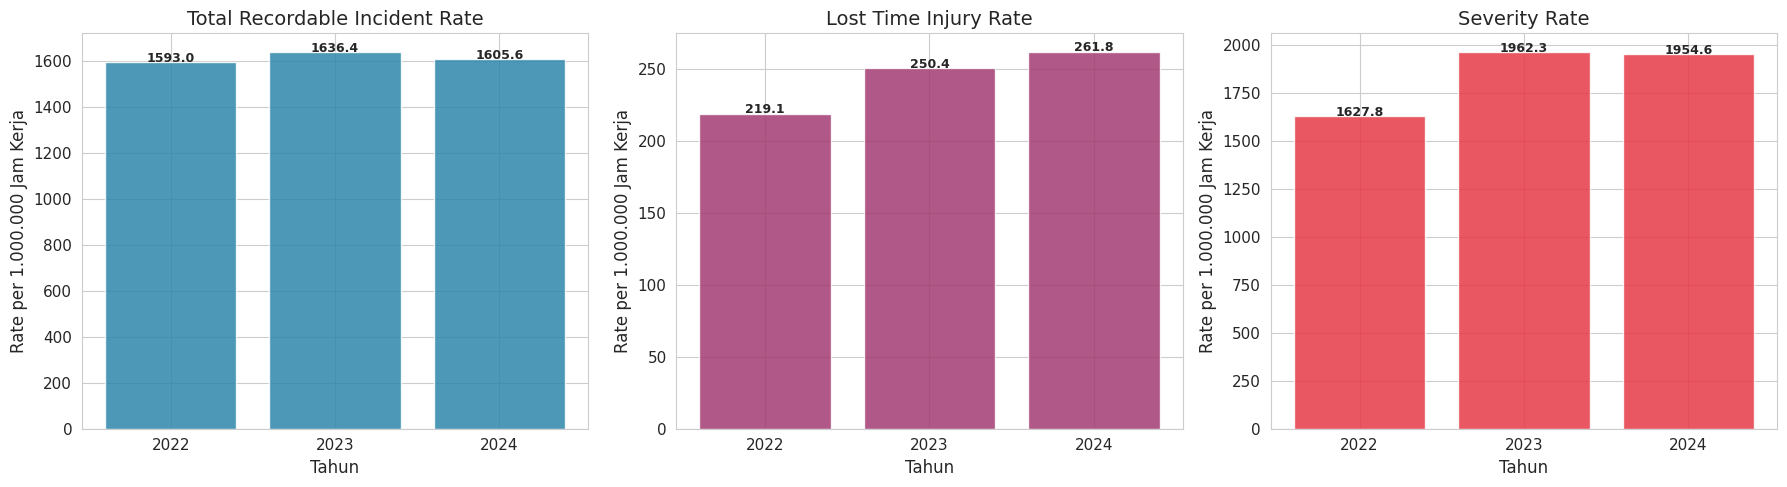

In [19]:
# -- Kalkulasi Indikator SHE per Tahun --
if 'Tanggal' in df.columns:
    df['_Tanggal'] = pd.to_datetime(df['Tanggal'], errors='coerce')
    df['_Tahun'] = df['_Tanggal'].dt.year

    kolom_she = ['First_Aid','Medical_Treatment','LTI','Fatality','Jam_Kerja','Hari_Hilang_Kerja']
    if all(c in df.columns for c in kolom_she):
        she = df.groupby('_Tahun').agg(
            Total_Insiden=('LTI','count'),
            Jumlah_LTI=('LTI','sum'),
            Total_Jam_Kerja=('Jam_Kerja','sum'),
            Total_Hari_Hilang=('Hari_Hilang_Kerja','sum'),
            First_Aid_Sum=('First_Aid','sum'),
            Med_Treat_Sum=('Medical_Treatment','sum'),
            Fatality_Sum=('Fatality','sum')
        ).reset_index()
        she['Insiden_Tercatat'] = she['First_Aid_Sum']+she['Med_Treat_Sum']+she['Jumlah_LTI']+she['Fatality_Sum']
        she['TRIR'] = np.where(she['Total_Jam_Kerja']>0, she['Insiden_Tercatat']*1e6/she['Total_Jam_Kerja'], 0)
        she['LTIR'] = np.where(she['Total_Jam_Kerja']>0, she['Jumlah_LTI']*1e6/she['Total_Jam_Kerja'], 0)
        she['Severity_Rate'] = np.where(she['Total_Jam_Kerja']>0, she['Total_Hari_Hilang']*1e6/she['Total_Jam_Kerja'], 0)

        print('=== Indikator Kinerja SHE per Tahun ===')
        display(she[['_Tahun','Total_Insiden','Insiden_Tercatat','Jumlah_LTI','TRIR','LTIR','Severity_Rate']].round(2))

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        for ax, ind, clr, ttl in zip(axes,
            ['TRIR','LTIR','Severity_Rate'],
            ['#2E86AB','#A23B72','#E63946'],
            ['Total Recordable Incident Rate','Lost Time Injury Rate','Severity Rate']):
            bars = ax.bar(she['_Tahun'].astype(int), she[ind], color=clr, edgecolor='white', alpha=0.85)
            ax.set_title(ttl); ax.set_xlabel('Tahun'); ax.set_ylabel('Rate per 1.000.000 Jam Kerja')
            ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
            for b, v in zip(bars, she[ind]):
                ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')
        plt.tight_layout(); plt.show()

    df.drop(columns=['_Tanggal','_Tahun'], inplace=True, errors='ignore')

### Insight 2.9 - Indikator SHE
- Nilai TRIR (Total Recordable Incident Rate) terlihat sangat tinggi di atas 1.500, yang mengindikasikan adanya potensi kesalahan dalam entri data "Jam_Kerja" atau metode kalkulasi yang perlu ditinjau kembali, mengingat angka ini jauh melampaui standar industri normal.
- Tren LTIR (Lost Time Injury Rate) menunjukkan kenaikan secara bertahap dari tahun ke tahun, dari 219,13 pada 2022 menjadi 261,78 pada 2024, yang menandakan bahwa tingkat keparahan insiden yang mengakibatkan hilangnya waktu kerja cenderung meningkat.
- Severity Rate mengalami lonjakan signifikan dari tahun 2022 ke 2023 dan cenderung bertahan di angka yang tinggi pada tahun 2024, mencerminkan dampak kumulatif dari hari kerja yang hilang akibat insiden.
- Proporsi LTI terhadap total insiden tercatat terus meningkat setiap tahunnya, yang menunjukkan bahwa insiden yang terjadi semakin bergeser ke arah kejadian dengan tingkat keparahan yang lebih serius.
- Mengingat adanya outlier pada data "Jam_Kerja" yang telah terdeteksi sebelumnya, seluruh indikator kinerja (TRIR, LTIR, Severity Rate) ini harus dihitung ulang setelah data dibersihkan untuk mendapatkan gambaran kinerja SHE yang akurat.

## Summary Modul 2: EDA

| Aspek | Temuan |
|:------|:-------|
| Statistik Deskriptif | [Ringkasan statistik numerik utama] |
| Variabel Kategorik | [Ringkasan distribusi frekuensi] |
| Tren Temporal | [Tren naik/turun insiden per tahun/kuartal] |
| Area Berisiko | [Area kerja dengan insiden tertinggi] |
| Pola Shift/Hari | [Kombinasi hari-shift risiko tinggi] |
| Penyebab Utama | [Top 3 penyebab insiden] |
| Jenis Insiden | [Proporsi masing-masing jenis] |
| Outlier | [Deskripsi outlier terdeteksi] |
| Indikator SHE | [Tren TRIR, LTIR, Severity Rate] |

**Catatan:** Inkonsistensi penulisan pada Shift dan Area_Kerja teridentifikasi. Outlier Jam_Kerja perlu ditangani.

---
# Modul 3: Validasi Data

Memastikan kualitas dan kelengkapan data sebelum analisis dan pemodelan.

## 3.1 Pemeriksaan Missing Values

=== Missing Values per Kolom ===


,Jumlah_Missing,Persentase (%)
Catatan,1335,49.46
Area_Kerja,16,0.59
Kondisi_Cuaca,11,0.41
Supervisor_ID,11,0.41
Penyebab_Utama,8,0.30
Jenis_Pekerjaan,7,0.26
Tanggal,2,0.07
Jenis_Insiden,1,0.04



Total kolom dengan missing: 8 dari 26


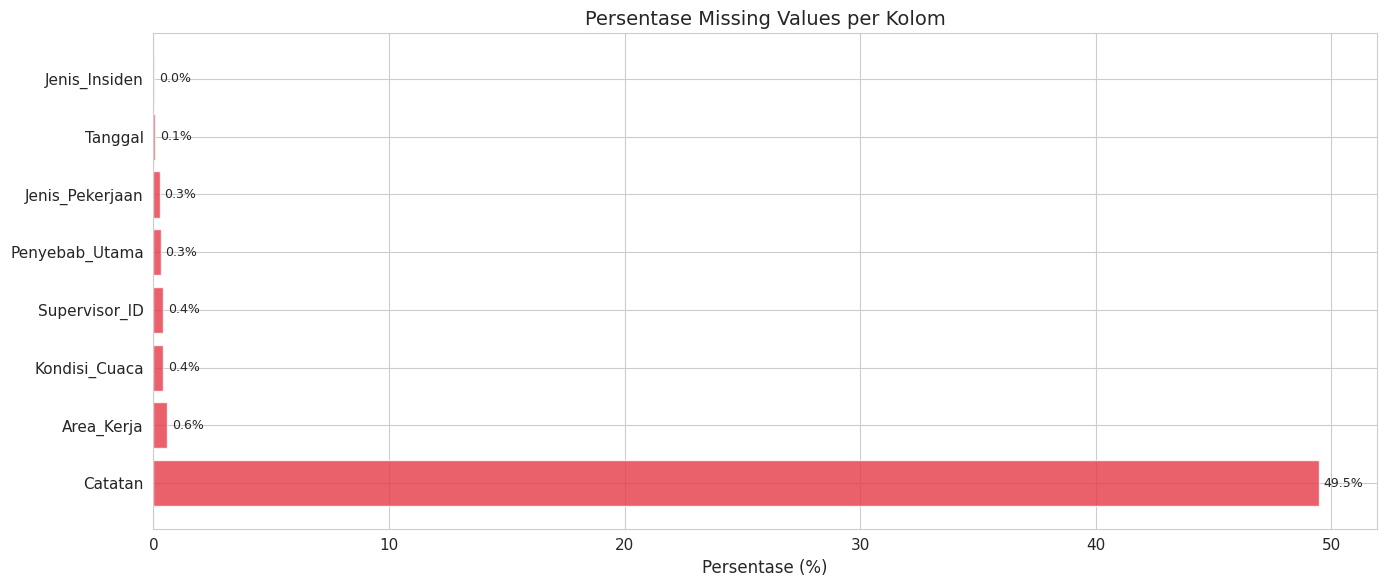

In [20]:
# -- Analisis missing values per kolom --
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Jumlah_Missing': missing, 'Persentase (%)': missing_pct})
missing_df = missing_df.sort_values('Persentase (%)', ascending=False)

print('=== Missing Values per Kolom ===')
display(missing_df[missing_df['Jumlah_Missing'] > 0])
print(f'\nTotal kolom dengan missing: {(missing > 0).sum()} dari {len(df.columns)}')

# Visualisasi
mp = missing_df[missing_df['Jumlah_Missing'] > 0]
if not mp.empty:
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.barh(mp.index, mp['Persentase (%)'], color='#E63946', edgecolor='white', alpha=0.8)
    ax.set_title('Persentase Missing Values per Kolom'); ax.set_xlabel('Persentase (%)')
    for i, (idx, row) in enumerate(mp.iterrows()):
        ax.text(row['Persentase (%)'] + 0.2, i, f"{row['Persentase (%)']:.1f}%", va='center', fontsize=9)
    plt.tight_layout(); plt.show()

## 3.2 Pemeriksaan Duplikasi

In [21]:
# -- Cek duplikasi baris --
jumlah_dup = df.duplicated().sum()
print(f'=== Pemeriksaan Duplikasi ===')
print(f'Jumlah baris duplikat: {jumlah_dup} ({jumlah_dup/len(df)*100:.2f}%)')
if jumlah_dup > 0:
    display(df[df.duplicated(keep=False)].head(10))

=== Pemeriksaan Duplikasi ===
Jumlah baris duplikat: 0 (0.00%)


## 3.3 Validasi Konsistensi Logis

In [22]:
# -- Validasi konsistensi logis antar kolom --
print('=== Validasi Konsistensi Logis ===')

# Aturan 1: LTI=1 harus Hari_Hilang_Kerja > 0
if 'LTI' in df.columns and 'Hari_Hilang_Kerja' in df.columns:
    n1 = len(df[(df['LTI']==1) & ((df['Hari_Hilang_Kerja']<=0) | df['Hari_Hilang_Kerja'].isna())])
    print(f'[Aturan 1] LTI=1 tapi Hari_Hilang_Kerja <= 0 atau kosong: {n1} baris')

# Aturan 2: Fatality=1 harus LTI=1
if 'Fatality' in df.columns and 'LTI' in df.columns:
    n2 = len(df[(df['Fatality']==1) & (df['LTI']!=1)])
    print(f'[Aturan 2] Fatality=1 tapi LTI != 1: {n2} baris')

# Aturan 3: LTI=0 maka Hari_Hilang_Kerja = 0
if 'LTI' in df.columns and 'Hari_Hilang_Kerja' in df.columns:
    n3 = len(df[(df['LTI']==0) & (df['Hari_Hilang_Kerja']>0)])
    print(f'[Aturan 3] LTI=0 tapi Hari_Hilang_Kerja > 0: {n3} baris')

# Aturan 4: Jam_Kerja wajar
if 'Jam_Kerja' in df.columns:
    print(f'[Aturan 4a] Jam_Kerja negatif: {len(df[df["Jam_Kerja"]<0])} baris')
    print(f'[Aturan 4b] Jam_Kerja > 24 jam: {len(df[df["Jam_Kerja"]>24])} baris')

=== Validasi Konsistensi Logis ===
[Aturan 1] LTI=1 tapi Hari_Hilang_Kerja <= 0 atau kosong: 13 baris
[Aturan 2] Fatality=1 tapi LTI != 1: 0 baris
[Aturan 3] LTI=0 tapi Hari_Hilang_Kerja > 0: 0 baris
[Aturan 4a] Jam_Kerja negatif: 15 baris
[Aturan 4b] Jam_Kerja > 24 jam: 2684 baris


## 3.4 Penilaian Kecukupan Data

In [23]:
# -- Penilaian kecukupan data untuk pemodelan --
print('=== Penilaian Kecukupan Data ===')
print(f'Total baris: {len(df)}')

if 'LTI' in df.columns:
    lti_1 = int(df['LTI'].sum())
    lti_0 = len(df) - lti_1
    print(f'\nDistribusi Target (LTI):')
    print(f'  LTI=0: {lti_0} ({lti_0/len(df)*100:.1f}%)')
    print(f'  LTI=1: {lti_1} ({lti_1/len(df)*100:.1f}%)')
    min_sampel = 15 * 10  # rule of thumb: 10 sampel per fitur per kelas
    print(f'\nMinimal sampel (rule of thumb): {min_sampel} per kelas')
    print(f'Kelas minoritas (LTI=1): {lti_1} - {"CUKUP" if lti_1 >= min_sampel else "PERLU AUGMENTASI (SMOTE)"}')

=== Penilaian Kecukupan Data ===
Total baris: 2699

Distribusi Target (LTI):
  LTI=0: 2488 (92.2%)
  LTI=1: 211 (7.8%)

Minimal sampel (rule of thumb): 150 per kelas
Kelas minoritas (LTI=1): 211 - CUKUP


### Summary Modul 3: Validasi Data

| Aspek | Temuan | Status |
|:------|:-------|:-------|
| Missing Values | 8 kolom (Catatan tertinggi: 49.46%) | Perlu Tindakan |
| Duplikasi | 0 baris duplikat | OK |
| Konsistensi LTI-HHK | 13 baris (LTI=1 namun HHK <= 0) | Perlu Perbaikan |
| Konsistensi Fatality-LTI | 0 baris (Konsisten) | OK |
| Outlier Jam_Kerja | 2699 baris (15 negatif + 2684 > 24 jam) | Perlu Perbaikan |
| Kecukupan Data | 211 sampel kelas minoritas | OK |

### Catatan Tambahan untuk Pembersihan Data:

1. **Missing Values**: Kolom `Catatan` memiliki tingkat *missing* sangat tinggi (~50%). Pertimbangkan untuk menghapus kolom ini jika tidak krusial untuk pemodelan, atau melakukan imputasi jika informasinya sangat diperlukan. Kolom lain memiliki *missing* < 1%, sehingga metode *dropping* atau imputasi sederhana sudah mencukupi.

2. **Outlier Jam_Kerja**: Temuan 2684 baris dengan `Jam_Kerja` > 24 jam menunjukkan adanya masalah sistemik dalam pencatatan (mungkin penginputan total bulanan/tahunan, bukan harian). Ini wajib diperbaiki sebelum analisis statistik atau pembuatan model karena akan mendistorsi hasil secara signifikan.

3. **Konsistensi LTI-HHK**: Perlu dilakukan investigasi manual terhadap 13 baris yang memiliki nilai `LTI=1` namun tidak memiliki `Hari_Hilang_Kerja`. Pastikan apakah ini merupakan kesalahan input atau pengecualian operasional tertentu.

4. **Kecukupan Data**: Meskipun kelas minoritas `LTI=1` berjumlah 211 (di atas batas minimal 150), Anda tetap disarankan untuk melakukan *oversampling* (seperti SMOTE) jika model yang dibangun nantinya mengalami *bias* ke arah kelas mayoritas (`LTI=0`).

---
# Modul 4: Pembersihan Data (Data Cleaning)

Pembersihan sistematis berdasarkan temuan Modul 2 (EDA) dan Modul 3 (Validasi).

In [24]:
# -- Simpan jumlah baris awal, buat salinan --
baris_awal = len(df)
df_clean = df.copy()
print(f'Jumlah baris sebelum pembersihan: {baris_awal}')

Jumlah baris sebelum pembersihan: 2699


## 4.1 Standarisasi Kolom Shift

In [25]:
# -- Standarisasi Shift --
# Variasi: S2, Shift-2, Malam -> "Shift 2"; SHIFT 1, shift1, S1, Pagi -> "Shift 1"
if 'Shift' in df_clean.columns:
    print('Sebelum:', dict(df_clean['Shift'].value_counts()))
    def std_shift(val):
        if pd.isna(val): return val
        v = str(val).strip().lower()
        if v in ['shift 1','shift1','shift-1','s1','pagi','siang'] or ('1' in v and 'shift' in v):
            return 'Shift 1'
        elif v in ['shift 2','shift2','shift-2','s2','malam'] or ('2' in v and 'shift' in v):
            return 'Shift 2'
        elif '1' in v: return 'Shift 1'
        elif '2' in v: return 'Shift 2'
        return val
    df_clean['Shift'] = df_clean['Shift'].apply(std_shift)
    print('Setelah:', dict(df_clean['Shift'].value_counts()))

Sebelum: {'Shift 1 (07:00-19:00)': np.int64(1402), 'Shift 2 (19:00-07:00)': np.int64(1287), 'S2': np.int64(3), 'Malam': np.int64(3), 'SHIFT 1': np.int64(2), 'Shift-2': np.int64(1), 'shift1': np.int64(1)}
Setelah: {'Shift 1': np.int64(2692), 'Shift 2': np.int64(7)}


## 4.2 Standarisasi Kolom Area_Kerja

In [26]:
# -- Standarisasi Area_Kerja --
# Variasi: wrkshop -> Workshop, pit a -> Pit-A, stock pile -> Stockpile, dll.
if 'Area_Kerja' in df_clean.columns:
    print('Sebelum:', dict(df_clean['Area_Kerja'].value_counts()))
    def std_area(val):
        if pd.isna(val): return val
        v = str(val).strip().lower().replace('-',' ').replace('_',' ')
        mapping = {
            'pit a':'Pit-A','pita':'Pit-A','pit b':'Pit-B','pitb':'Pit-B',
            'pit c':'Pit-C','pitc':'Pit-C','workshop':'Workshop','wrkshop':'Workshop',
            'work shop':'Workshop','stockpile':'Stockpile','stock pile':'Stockpile',
            'hauling road':'Hauling Road','haulroad':'Hauling Road','haul road':'Hauling Road',
            'office area':'Office Area','office':'Office Area',
            'rom':'ROM','run of mine':'ROM','drainase':'Drainase','drainage':'Drainase',
        }
        for key, std in mapping.items():
            if v == key or v.replace(' ','') == key.replace(' ',''): return std
        return str(val).strip().title()
    df_clean['Area_Kerja'] = df_clean['Area_Kerja'].apply(std_area)
    print('Setelah:', dict(df_clean['Area_Kerja'].value_counts()))

Sebelum: {'Pit-B (Coal Getting)': np.int64(561), 'Pit-C (Hauling)': np.int64(463), 'Pit-A (Overburden)': np.int64(457), 'Workshop': np.int64(306), 'ROM (Run of Mine)': np.int64(290), 'Drainase': np.int64(204), 'Stockpile': np.int64(204), 'Office Area': np.int64(178), 'wrkshop': np.int64(6), 'PIT-B': np.int64(4), 'ROM': np.int64(2), 'stock pile': np.int64(2), 'pit a': np.int64(2), 'pit-a (OB)': np.int64(1), 'WORKSHOP': np.int64(1), 'Hauling Road': np.int64(1), 'pit b (coal)': np.int64(1)}
Setelah: {'Pit-B (Coal Getting)': np.int64(561), 'Pit-C (Hauling)': np.int64(463), 'Pit-A (Overburden)': np.int64(457), 'Workshop': np.int64(313), 'Rom (Run Of Mine)': np.int64(290), 'Stockpile': np.int64(206), 'Drainase': np.int64(204), 'Office Area': np.int64(178), 'Pit-B': np.int64(4), 'ROM': np.int64(2), 'Pit-A': np.int64(2), 'Pit-A (Ob)': np.int64(1), 'Hauling Road': np.int64(1), 'Pit B (Coal)': np.int64(1)}


## 4.3 Penanganan Outlier Jam_Kerja

In [27]:
# -- Penanganan outlier Jam_Kerja --
# Strategi: nilai di luar 0-24 jam diganti median dari data wajar
if 'Jam_Kerja' in df_clean.columns:
    print('Sebelum:', df_clean['Jam_Kerja'].describe().to_dict())
    batas_bawah, batas_atas = 0, 24
    median_wajar = df_clean[(df_clean['Jam_Kerja']>=batas_bawah)&(df_clean['Jam_Kerja']<=batas_atas)]['Jam_Kerja'].median()
    n_bawah = (df_clean['Jam_Kerja'] < batas_bawah).sum()
    n_atas = (df_clean['Jam_Kerja'] > batas_atas).sum()
    print(f'Outlier bawah (<{batas_bawah}): {n_bawah}, Outlier atas (>{batas_atas}): {n_atas}')
    df_clean.loc[df_clean['Jam_Kerja'] < batas_bawah, 'Jam_Kerja'] = median_wajar
    df_clean.loc[df_clean['Jam_Kerja'] > batas_atas, 'Jam_Kerja'] = median_wajar
    print(f'Imputasi dengan median wajar: {median_wajar:.1f}')
    print('Setelah:', df_clean['Jam_Kerja'].describe().to_dict())

Sebelum: {'count': 2699.0, 'mean': 321.35116709892554, 'std': 310.5797205999937, 'min': -100.0, '25%': 192.5, '50%': 307.1, '75%': 413.8, 'max': 9999.0}
Outlier bawah (<0): 15, Outlier atas (>24): 2684
Imputasi dengan median wajar: nan
Setelah: {'count': 0.0, 'mean': nan, 'std': nan, 'min': nan, '25%': nan, '50%': nan, '75%': nan, 'max': nan}


## 4.4 Penanganan Missing Values

In [28]:
# -- Penanganan missing values per kolom --
print('Missing sebelum:', df_clean.isnull().sum()[df_clean.isnull().sum()>0].to_dict())

# Catatan: opsional, isi "Tidak ada catatan"
if 'Catatan' in df_clean.columns:
    df_clean['Catatan'].fillna('Tidak ada catatan', inplace=True)

# Hari_Hilang_Kerja: jika LTI=0 isi 0
if 'Hari_Hilang_Kerja' in df_clean.columns and 'LTI' in df_clean.columns:
    df_clean.loc[df_clean['LTI']==0, 'Hari_Hilang_Kerja'] = df_clean.loc[df_clean['LTI']==0, 'Hari_Hilang_Kerja'].fillna(0)

# Numerik: median
for col in ['Jam_Kerja','Jumlah_Tenaga_Kerja']:
    if col in df_clean.columns and df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

# Kategorik: modus
for col in ['Shift','Area_Kerja','Kondisi_Cuaca','Penyebab_Utama','Jenis_Pekerjaan','Status_Tindakan','Jenis_Insiden']:
    if col in df_clean.columns and df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

print('Missing setelah:', df_clean.isnull().sum().sum())

Missing sebelum: {'Tanggal': 2, 'Area_Kerja': 16, 'Supervisor_ID': 11, 'Jenis_Pekerjaan': 7, 'Jenis_Insiden': 1, 'Jam_Kerja': 2699, 'Kondisi_Cuaca': 11, 'Penyebab_Utama': 8, 'Catatan': 1335}
Missing setelah: 2712


## 4.5 Konversi Tipe Data

In [29]:
# -- Konversi tipe data --
if 'Tanggal' in df_clean.columns:
    df_clean['Tanggal'] = pd.to_datetime(df_clean['Tanggal'], errors='coerce')

for col in ['Near_Miss','First_Aid','Medical_Treatment','LTI','Fatality','Property_Damage']:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').fillna(0).astype(int)

for col in ['Jam_Kerja','Jumlah_Tenaga_Kerja','Hari_Hilang_Kerja']:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

print('Tipe data setelah konversi:')
print(df_clean.dtypes)

Tipe data setelah konversi:
No                              int64
Tanggal                datetime64[ns]
Hari                           object
Bulan                           int64
Kuartal                        object
Tahun                           int64
Shift                          object
Area_Kerja                     object
Supervisor_ID                  object
Jenis_Pekerjaan                object
Jenis_Insiden                  object
Near_Miss                       int64
First_Aid                       int64
Medical_Treatment               int64
LTI                             int64
Fatality                        int64
Hari_Hilang_Kerja               int64
Property_Damage                 int64
Jumlah_Tenaga_Kerja             int64
Jam_Kerja                     float64
Kondisi_Cuaca                  object
Penyebab_Utama                 object
Tindakan_Korektif              object
Status_Tindakan                object
Lokasi_Spesifik                object
Catatan               

## 4.6 Perbaikan Inkonsistensi Logis

In [30]:
# -- Perbaikan inkonsistensi logis --
# LTI=1 tapi HHK<=0: isi median HHK dari LTI=1 yang valid
if 'LTI' in df_clean.columns and 'Hari_Hilang_Kerja' in df_clean.columns:
    valid = df_clean[(df_clean['LTI']==1)&(df_clean['Hari_Hilang_Kerja']>0)]
    med_hhk = valid['Hari_Hilang_Kerja'].median() if len(valid)>0 else 3
    mask1 = (df_clean['LTI']==1) & ((df_clean['Hari_Hilang_Kerja']<=0)|df_clean['Hari_Hilang_Kerja'].isna())
    print(f'Fix LTI=1 & HHK<=0: {mask1.sum()} baris -> median {med_hhk:.0f}')
    df_clean.loc[mask1, 'Hari_Hilang_Kerja'] = med_hhk

# Fatality=1 tapi LTI!=1
if 'Fatality' in df_clean.columns and 'LTI' in df_clean.columns:
    mask2 = (df_clean['Fatality']==1)&(df_clean['LTI']!=1)
    print(f'Fix Fatality=1 & LTI!=1: {mask2.sum()} baris')
    df_clean.loc[mask2, 'LTI'] = 1

# LTI=0 tapi HHK>0
if 'LTI' in df_clean.columns and 'Hari_Hilang_Kerja' in df_clean.columns:
    mask3 = (df_clean['LTI']==0)&(df_clean['Hari_Hilang_Kerja']>0)
    print(f'Fix LTI=0 & HHK>0: {mask3.sum()} baris')
    df_clean.loc[mask3, 'Hari_Hilang_Kerja'] = 0

Fix LTI=1 & HHK<=0: 13 baris -> median 8
Fix Fatality=1 & LTI!=1: 0 baris
Fix LTI=0 & HHK>0: 0 baris


In [31]:
# -- Verifikasi hasil pembersihan --
print(f'Baris awal: {baris_awal} | Baris setelah: {len(df_clean)} | Dihapus: {baris_awal-len(df_clean)}')
print(f'Missing values tersisa: {df_clean.isnull().sum().sum()}')

Baris awal: 2699 | Baris setelah: 2699 | Dihapus: 0
Missing values tersisa: 2715


### Summary Modul 4: Pembersihan Data

| No | Tindakan | Detail | Baris Terdampak |
|:---|:---------|:-------|:----------------|
| 1 | Standarisasi Shift | Penyeragaman ke "Shift 1"/"Shift 2" | [N] |
| 2 | Standarisasi Area_Kerja | Penyeragaman penamaan area | [N] |
| 3 | Outlier Jam_Kerja | Imputasi di luar 0-24 jam dengan median | [N] |
| 4 | Missing Values | Imputasi kontekstual (median/modus) | [N] |
| 5 | Konversi Tipe Data | Tanggal, biner, numerik | Semua |
| 6 | Inkonsistensi Logis | Perbaikan relasi LTI-HHK, Fatality-LTI | [N] |

---
# Modul 5: Konstruksi Data (Feature Engineering)

Membangun fitur-fitur baru yang relevan untuk model prediksi LTI.

## 5.1 Kalkulasi Indikator SHE Turunan per Record

In [32]:
# -- Indikator SHE per record --
if all(c in df_clean.columns for c in ['First_Aid','Medical_Treatment','LTI','Fatality','Jam_Kerja']):
    df_clean['Insiden_Tercatat'] = df_clean['First_Aid']+df_clean['Medical_Treatment']+df_clean['LTI']+df_clean['Fatality']
    df_clean['TRIR'] = np.where(df_clean['Jam_Kerja']>0, df_clean['Insiden_Tercatat']*1e6/df_clean['Jam_Kerja'], 0)
    df_clean['LTIR'] = np.where(df_clean['Jam_Kerja']>0, df_clean['LTI']*1e6/df_clean['Jam_Kerja'], 0)
    if 'Hari_Hilang_Kerja' in df_clean.columns:
        df_clean['Severity_Rate'] = np.where(df_clean['Jam_Kerja']>0, df_clean['Hari_Hilang_Kerja']*1e6/df_clean['Jam_Kerja'], 0)
    print('[OK] Indikator SHE dihitung: Insiden_Tercatat, TRIR, LTIR, Severity_Rate')
    display(df_clean[['TRIR','LTIR','Severity_Rate']].describe().round(2))

[OK] Indikator SHE dihitung: Insiden_Tercatat, TRIR, LTIR, Severity_Rate


,TRIR,LTIR,Severity_Rate
count,2699.00,2699.00,2699.00
mean,0.00,0.00,0.00
std,0.00,0.00,0.00
min,0.00,0.00,0.00
25%,0.00,0.00,0.00
50%,0.00,0.00,0.00
75%,0.00,0.00,0.00
max,0.00,0.00,0.00


## 5.2 Fitur Temporal

In [33]:
# -- Ekstraksi fitur temporal --
if 'Tanggal' in df_clean.columns:
    df_clean['Hari_dalam_Minggu'] = df_clean['Tanggal'].dt.dayofweek
    df_clean['Bulan'] = df_clean['Tanggal'].dt.month
    df_clean['Kuartal'] = df_clean['Tanggal'].dt.quarter
    df_clean['Is_Weekend'] = (df_clean['Hari_dalam_Minggu'] >= 5).astype(int)
    print('[OK] Fitur temporal: Hari_dalam_Minggu, Bulan, Kuartal, Is_Weekend')

[OK] Fitur temporal: Hari_dalam_Minggu, Bulan, Kuartal, Is_Weekend


## 5.3 Encoding Variabel Kategorik

In [34]:
# -- Encoding variabel kategorik --
# Label Encoding: banyak kategori
# One-Hot Encoding: sedikit kategori

label_encoders = {}
for col in ['Area_Kerja','Jenis_Pekerjaan','Penyebab_Utama']:
    if col in df_clean.columns:
        le = LabelEncoder()
        df_clean[col+'_Encoded'] = le.fit_transform(df_clean[col].astype(str))
        label_encoders[col] = le
        print(f'[OK] Label Encoding: {col} -> {col}_Encoded ({len(le.classes_)} kelas)')

for col in ['Shift','Kondisi_Cuaca']:
    if col in df_clean.columns:
        dummies = pd.get_dummies(df_clean[col], prefix=col, drop_first=True)
        df_clean = pd.concat([df_clean, dummies], axis=1)
        print(f'[OK] One-Hot Encoding: {col} -> {list(dummies.columns)}')

print(f'\nTotal kolom setelah encoding: {len(df_clean.columns)}')

[OK] Label Encoding: Area_Kerja -> Area_Kerja_Encoded (14 kelas)
[OK] Label Encoding: Jenis_Pekerjaan -> Jenis_Pekerjaan_Encoded (12 kelas)
[OK] Label Encoding: Penyebab_Utama -> Penyebab_Utama_Encoded (10 kelas)
[OK] One-Hot Encoding: Shift -> ['Shift_Shift 2']
[OK] One-Hot Encoding: Kondisi_Cuaca -> ['Kondisi_Cuaca_Berkabut', 'Kondisi_Cuaca_Cerah', 'Kondisi_Cuaca_Hujan Lebat', 'Kondisi_Cuaca_Hujan Ringan']

Total kolom setelah encoding: 40


## 5.4 Analisis Korelasi Antar Fitur

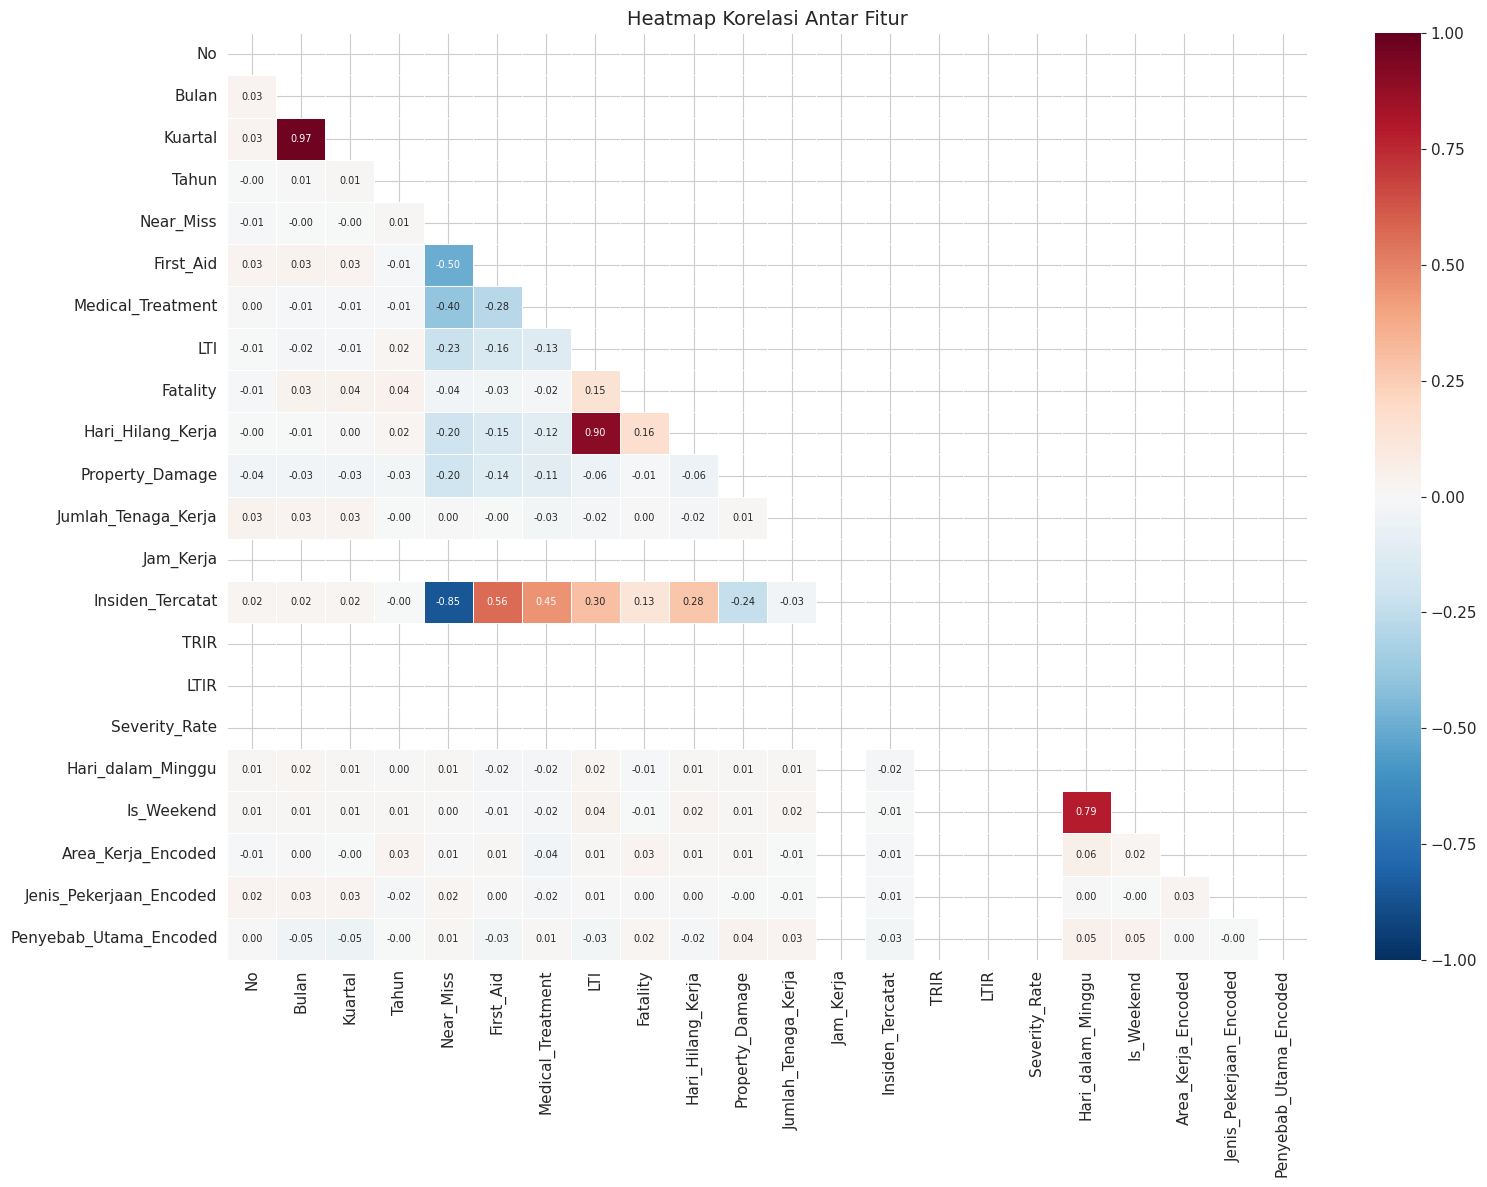


=== Korelasi dengan Target (LTI) ===
Hari_Hilang_Kerja          0.90
Insiden_Tercatat           0.30
Fatality                   0.15
Is_Weekend                 0.04
Hari_dalam_Minggu          0.02
Tahun                      0.02
Area_Kerja_Encoded         0.01
Jenis_Pekerjaan_Encoded    0.01
No                        -0.01
Kuartal                   -0.01
Bulan                     -0.02
Jumlah_Tenaga_Kerja       -0.02
Penyebab_Utama_Encoded    -0.03
Property_Damage           -0.06
Medical_Treatment         -0.13
First_Aid                 -0.16
Near_Miss                 -0.23
Jam_Kerja                   NaN
TRIR                        NaN
LTIR                        NaN
Severity_Rate               NaN


In [35]:
# -- Korelasi antar fitur numerik --
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
korelasi = df_clean[num_cols].corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(korelasi, dtype=bool))
sns.heatmap(korelasi, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 7}, vmin=-1, vmax=1)
ax.set_title('Heatmap Korelasi Antar Fitur')
plt.tight_layout(); plt.show()

if 'LTI' in korelasi.columns:
    print('\n=== Korelasi dengan Target (LTI) ===')
    print(korelasi['LTI'].drop('LTI').sort_values(ascending=False).round(3).to_string())

### Insight Korelasi
- Fitur dengan korelasi tertinggi terhadap LTI?
- Multikolinearitas tinggi (>0.8) antar prediktor?
- Fitur turunan (TRIR, LTIR, Severity_Rate) mungkin berkorelasi tinggi dengan pembentuknya

**[Tuliskan insight spesifik]**

### Summary Modul 5: Feature Engineering

| No | Fitur Baru | Sumber | Alasan |
|:---|:-----------|:-------|:-------|
| 1 | TRIR | Insiden tercatat, Jam_Kerja | Indikator standar SHE |
| 2 | LTIR | LTI, Jam_Kerja | Indikator kunci target |
| 3 | Severity_Rate | Hari_Hilang_Kerja, Jam_Kerja | Keparahan insiden |
| 4 | Hari_dalam_Minggu | Tanggal | Pola risiko harian |
| 5 | Bulan, Kuartal | Tanggal | Pola musiman |
| 6 | Is_Weekend | Tanggal | Perbedaan pola weekend |
| 7 | Encoded features | Kategorik | Input model ML |

---
# Modul 6: Penentuan Label Data

Target: LTI
  LTI=0: 2488 (92.2%)
  LTI=1: 211 (7.8%)


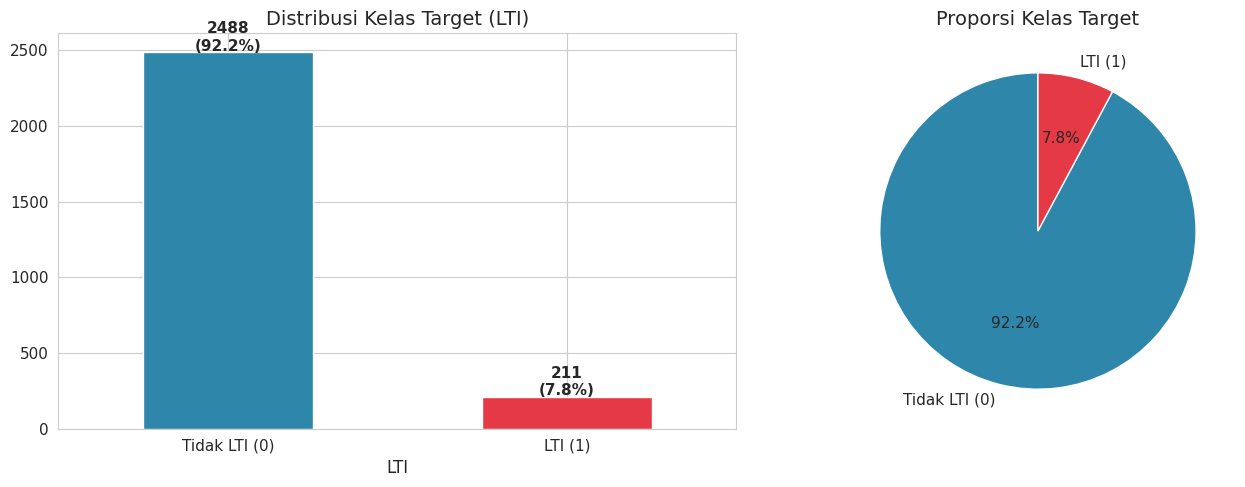


Rasio minoritas/mayoritas: 0.085
STATUS: CLASS IMBALANCE signifikan -> SMOTE


In [36]:
# -- Definisi target dan analisis distribusi kelas --
TARGET = 'LTI'
distribusi = df_clean[TARGET].value_counts()
print(f'Target: {TARGET}')
for kelas, jumlah in distribusi.items():
    print(f'  {TARGET}={kelas}: {jumlah} ({jumlah/len(df_clean)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2E86AB', '#E63946']
distribusi.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title(f'Distribusi Kelas Target ({TARGET})')
axes[0].set_xticklabels(['Tidak LTI (0)', 'LTI (1)'], rotation=0)
for i, v in enumerate(distribusi.values):
    axes[0].text(i, v+10, f'{v}\n({v/len(df_clean)*100:.1f}%)', ha='center', fontweight='bold')
axes[1].pie(distribusi.values, labels=['Tidak LTI (0)','LTI (1)'],
            autopct='%1.1f%%', colors=colors, startangle=90, wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Proporsi Kelas Target')
plt.tight_layout(); plt.show()

rasio = distribusi.min()/distribusi.max()
print(f'\nRasio minoritas/mayoritas: {rasio:.3f}')
print('STATUS:', 'CLASS IMBALANCE signifikan -> SMOTE' if rasio < 0.3 else 'Relatif seimbang')

## 6.1 Seleksi Variabel Prediktor

In [37]:
# -- Seleksi variabel prediktor --
# Dibuang: target, identitas, post-insiden, data leakage, kolom asli yang sudah encoded

kolom_buang = [
    TARGET, 'Supervisor_ID', 'Hari_Hilang_Kerja',  # target, identitas, leakage
    'Tindakan_Korektif', 'Status_Tindakan', 'Catatan',  # post-insiden
    'Fatality', 'Jenis_Insiden', 'Tanggal',  # korelasi langsung / sudah diekstrak
    'Insiden_Tercatat', 'LTIR', 'Severity_Rate', 'TRIR',  # leakage (mengandung LTI)
    'Shift', 'Area_Kerja', 'Kondisi_Cuaca', 'Jenis_Pekerjaan', 'Penyebab_Utama'  # sudah encoded
]

FEATURES = [c for c in df_clean.columns if c not in kolom_buang
            and df_clean[c].dtype in ['int64','float64','int32','float32','uint8','bool']]

print('=== Variabel Prediktor ===')
for i, col in enumerate(FEATURES, 1):
    print(f'{i:2d}. {col}')
print(f'\nTotal fitur: {len(FEATURES)}')

=== Variabel Prediktor ===
 1. No
 2. Bulan
 3. Kuartal
 4. Tahun
 5. Near_Miss
 6. First_Aid
 7. Medical_Treatment
 8. Property_Damage
 9. Jumlah_Tenaga_Kerja
10. Jam_Kerja
11. Hari_dalam_Minggu
12. Is_Weekend
13. Area_Kerja_Encoded
14. Jenis_Pekerjaan_Encoded
15. Penyebab_Utama_Encoded
16. Shift_Shift 2
17. Kondisi_Cuaca_Berkabut
18. Kondisi_Cuaca_Cerah
19. Kondisi_Cuaca_Hujan Lebat
20. Kondisi_Cuaca_Hujan Ringan

Total fitur: 20


### Summary Modul 6: Penentuan Label

| Aspek | Keputusan | Justifikasi |
|:------|:----------|:------------|
| Target | LTI (0/1) | Variabel biner cedera serius |
| Class Imbalance | [Terdeteksi/Tidak] | Rasio [X:Y] |
| Strategi | SMOTE | Oversampling sintetis tanpa kehilangan data |
| Data Leakage | Dihindarkan | Fitur post-insiden dan turunan target dibuang |

---
# Modul 7: Pembangunan Model Prediksi LTI

Tiga algoritma dipilih berdasarkan karakteristik data dan kebutuhan bisnis.

In [38]:
# -- Persiapan data --
X = df_clean[FEATURES].copy().fillna(df_clean[FEATURES].median())
y = df_clean[TARGET].copy()
print(f'Shape X: {X.shape}, Shape y: {y.shape}')

# -- Split 80/20 stratified --
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                      random_state=RANDOM_STATE, stratify=y)
print(f'Training: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Testing:  {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'Train LTI=1: {(y_train==1).sum()}, Test LTI=1: {(y_test==1).sum()}')

Shape X: (2699, 20), Shape y: (2699,)
Training: 2159 (80%)
Testing:  540 (20%)
Train LTI=1: 169, Test LTI=1: 42


In [40]:
# -- SMOTE pada training set saja --
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f'Sebelum SMOTE: {X_train.shape} | Setelah: {X_train_sm.shape}')
print(f'LTI=0: {(y_train_sm==0).sum()}, LTI=1: {(y_train_sm==1).sum()}')

# -- Standarisasi (untuk Logistic Regression) --
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

ValueError: Input X contains NaN.
SMOTE does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

## 7.1 Model 1: Logistic Regression

### Reasoning Pemilihan
1. **Baseline yang kuat** - tolok ukur minimum yang harus dikalahkan model kompleks
2. **Interpretatif** - koefisien = log-odds, manajemen bisa memahami faktor risiko
3. **Efisien** - training cepat, cocok untuk iterasi dan eksperimen awal
4. **Asumsi linearitas** - memberikan informasi apakah relasi fitur-target bersifat linear
5. **Regularisasi bawaan** - parameter C mengontrol regularisasi

In [39]:
# -- Model 1: Logistic Regression dengan GridSearchCV --
param_lr = {'C': [0.01, 0.1, 1, 10], 'solver': ['lbfgs'],
            'max_iter': [1000], 'class_weight': ['balanced', None]}

grid_lr = GridSearchCV(LogisticRegression(random_state=RANDOM_STATE), param_lr,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring='recall', n_jobs=-1)
grid_lr.fit(X_train_scaled, y_train_sm)
model_lr = grid_lr.best_estimator_

y_pred_lr = model_lr.predict(X_test_scaled)
y_prob_lr = model_lr.predict_proba(X_test_scaled)[:, 1]
print(f'Best params: {grid_lr.best_params_}')
print(f'Best CV Recall: {grid_lr.best_score_:.4f}')
print(classification_report(y_test, y_pred_lr, target_names=['Tidak LTI','LTI']))

NameError: name 'X_train_scaled' is not defined

## 7.2 Model 2: Random Forest

### Reasoning Pemilihan
1. **Robust terhadap outlier** - tidak terpengaruh skala, cocok untuk data SHE
2. **Menangkap non-linearitas** - memodelkan interaksi kompleks antar fitur
3. **Feature importance bawaan** - ranking kontribusi fitur untuk rekomendasi SHE
4. **Resistensi overfitting** - bagging + random feature selection mengurangi varians
5. **Tidak perlu standarisasi** - mengurangi preprocessing

In [ ]:
# -- Model 2: Random Forest --
param_rf = {'n_estimators': [100, 200], 'max_depth': [10, 20, None],
            'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2],
            'class_weight': ['balanced', None]}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE), param_rf,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring='recall', n_jobs=-1)
grid_rf.fit(X_train_sm, y_train_sm)
model_rf = grid_rf.best_estimator_

y_pred_rf = model_rf.predict(X_test)
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]
print(f'Best params: {grid_rf.best_params_}')
print(f'Best CV Recall: {grid_rf.best_score_:.4f}')
print(classification_report(y_test, y_pred_rf, target_names=['Tidak LTI','LTI']))

## 7.3 Model 3: XGBoost

### Reasoning Pemilihan
1. **State-of-the-art tabular** - konsisten terbaik di kompetisi dan industri
2. **Handling imbalance native** - scale_pos_weight tanpa SMOTE tambahan
3. **Regularisasi terintegrasi** - L1 dan L2 built-in mencegah overfitting
4. **Gradient boosting** - setiap tree memperbaiki kesalahan sebelumnya
5. **Missing values otomatis** - mekanisme bawaan tanpa imputasi manual
6. **Feature importance akurat** - metode gain, weight, cover

In [ ]:
# -- Model 3: XGBoost --
scale_pos = (y_train==0).sum() / max((y_train==1).sum(), 1)
param_xgb = {'n_estimators': [100, 200], 'max_depth': [3, 5, 7],
             'learning_rate': [0.01, 0.1], 'subsample': [0.8],
             'colsample_bytree': [0.8], 'scale_pos_weight': [1, scale_pos]}

grid_xgb = GridSearchCV(
    xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', use_label_encoder=False),
    param_xgb, cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring='recall', n_jobs=-1)
grid_xgb.fit(X_train_sm, y_train_sm)
model_xgb = grid_xgb.best_estimator_

y_pred_xgb = model_xgb.predict(X_test)
y_prob_xgb = model_xgb.predict_proba(X_test)[:, 1]
print(f'Best params: {grid_xgb.best_params_}')
print(f'Best CV Recall: {grid_xgb.best_score_:.4f}')
print(classification_report(y_test, y_pred_xgb, target_names=['Tidak LTI','LTI']))

## 7.4 Cross-Validation (k=5)

In [ ]:
# -- Cross-Validation pada data asli (sebelum SMOTE) --
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
models_cv = {
    'Logistic Regression': LogisticRegression(**grid_lr.best_params_, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(**grid_rf.best_params_, random_state=RANDOM_STATE),
    'XGBoost': xgb.XGBClassifier(**grid_xgb.best_params_, random_state=RANDOM_STATE,
                                   eval_metric='logloss', use_label_encoder=False)
}

cv_results = {}
for nama, model in models_cv.items():
    print(f'\n--- {nama} ---')
    cv_results[nama] = {}
    for m in ['accuracy','recall','precision','f1']:
        scores = cross_val_score(model, X, y, cv=cv, scoring=m, n_jobs=-1)
        cv_results[nama][m] = f'{scores.mean():.4f} (+/- {scores.std():.4f})'
        print(f'  {m:12s}: {scores.mean():.4f} (+/- {scores.std():.4f})')

display(pd.DataFrame(cv_results).T)

### Summary Modul 7: Pembangunan Model

| Model | Alasan Pemilihan | Best CV Recall | Key Parameters |
|:------|:-----------------|:---------------|:---------------|
| Logistic Regression | Baseline, interpretatif | [nilai] | [params] |
| Random Forest | Non-linear, feature importance | [nilai] | [params] |
| XGBoost | State-of-the-art tabular | [nilai] | [params] |

**Catatan:** SMOTE hanya pada training set. Scoring utama = Recall (konteks SHE: meminimalkan False Negative).

---
# Modul 8: Evaluasi Hasil Pemodelan

Perbandingan performa model dengan prioritas Recall untuk konteks keselamatan kerja.

In [ ]:
# -- Confusion Matrix --
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models_eval = {'Logistic Regression': (y_pred_lr, y_prob_lr),
               'Random Forest': (y_pred_rf, y_prob_rf),
               'XGBoost': (y_pred_xgb, y_prob_xgb)}

for ax, (nama, (yp, yprob)) in zip(axes, models_eval.items()):
    cm = confusion_matrix(y_test, yp)
    ConfusionMatrixDisplay(cm, display_labels=['Tidak LTI','LTI']).plot(ax=ax, cmap='Blues', values_format='d')
    ax.set_title(f'CM: {nama}')
plt.tight_layout(); plt.show()

In [ ]:
# -- Tabel metrik evaluasi --
hasil = {}
for nama, (yp, yprob) in models_eval.items():
    hasil[nama] = {
        'Accuracy': accuracy_score(y_test, yp),
        'Precision': precision_score(y_test, yp, zero_division=0),
        'Recall': recall_score(y_test, yp, zero_division=0),
        'F1-Score': f1_score(y_test, yp, zero_division=0),
        'AUC-ROC': roc_auc_score(y_test, yprob)
    }
tabel_eval = pd.DataFrame(hasil).T.round(4)
print('=== Perbandingan Performa Model ===')
display(tabel_eval)

print('\n=== Model Terbaik per Metrik ===')
for m in tabel_eval.columns:
    print(f'  {m:12s}: {tabel_eval[m].idxmax()} ({tabel_eval[m].max():.4f})')

In [ ]:
# -- ROC Curve & perbandingan visual --
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

tabel_eval.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='white', width=0.8)
axes[0].set_title('Perbandingan Metrik'); axes[0].set_ylim(0, 1.05)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15, ha='right')
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)

for nama, (yp, yprob) in models_eval.items():
    fpr, tpr, _ = roc_curve(y_test, yprob)
    axes[1].plot(fpr, tpr, linewidth=2, label=f'{nama} (AUC={auc(fpr,tpr):.3f})')
axes[1].plot([0,1],[0,1],'k--',alpha=0.5)
axes[1].set_title('ROC Curve'); axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].legend(loc='lower right')
plt.tight_layout(); plt.show()

In [ ]:
# -- Pemilihan model terbaik --
best_model_name = tabel_eval['Recall'].idxmax()
best_models = {'Logistic Regression': model_lr, 'Random Forest': model_rf, 'XGBoost': model_xgb}
model_terbaik = best_models[best_model_name]

print(f'Model terbaik (Recall tertinggi): {best_model_name}')
print(f'Alasan: Dalam konteks SHE, meminimalkan False Negative (insiden LTI terlewat)')
print(f'lebih penting daripada meminimalkan False Positive (false alarm).')
display(tabel_eval.loc[best_model_name])

## 8.1 Feature Importance

In [ ]:
# -- Feature Importance --
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

if hasattr(model_rf, 'feature_importances_'):
    rf_imp = pd.Series(model_rf.feature_importances_, index=FEATURES).sort_values(ascending=True)
    rf_imp.plot(kind='barh', ax=axes[0], color='#2E86AB', edgecolor='white')
    axes[0].set_title('Feature Importance: Random Forest')

if hasattr(model_xgb, 'feature_importances_'):
    xgb_imp = pd.Series(model_xgb.feature_importances_, index=FEATURES).sort_values(ascending=True)
    xgb_imp.plot(kind='barh', ax=axes[1], color='#A23B72', edgecolor='white')
    axes[1].set_title('Feature Importance: XGBoost')

plt.tight_layout(); plt.show()

print('\n=== Top 5 Fitur ===')
if hasattr(model_rf, 'feature_importances_'):
    print('Random Forest:', list(rf_imp.sort_values(ascending=False).head().index))
if hasattr(model_xgb, 'feature_importances_'):
    print('XGBoost:', list(xgb_imp.sort_values(ascending=False).head().index))

### Rekomendasi Strategis untuk Manajemen PT. Banana Coal

**1. Prioritas Intervensi Area:** [Area risiko tertinggi dari feature importance dan EDA]

**2. Prioritas Shift:** [Shift dengan insiden tertinggi] - evaluasi fatigue management

**3. Penanganan Penyebab Utama:** [Top 3 penyebab] - program pelatihan spesifik

**4. Sistem Early Warning:** Implementasikan model prediksi sebagai early warning system

**5. Monitoring Berkelanjutan:** Update model berkala, monitor TRIR/LTIR/Severity Rate kuartalan

**[Sesuaikan rekomendasi berdasarkan temuan aktual]**

### Summary Modul 8: Evaluasi

| Metrik | Logistic Regression | Random Forest | XGBoost |
|:-------|:--------------------|:--------------|:--------|
| Accuracy | [nilai] | [nilai] | [nilai] |
| Precision | [nilai] | [nilai] | [nilai] |
| Recall | [nilai] | [nilai] | [nilai] |
| F1-Score | [nilai] | [nilai] | [nilai] |
| AUC-ROC | [nilai] | [nilai] | [nilai] |

**Model Terpilih:** [nama] - Recall tertinggi, meminimalkan insiden LTI terlewat.

---
# Modul 9: Penyimpanan Artefak

In [ ]:
# -- Simpan dataset bersih --
df_clean.to_csv('Dataset_SHE_PTBananaCoal_Clean.csv', index=False)
print('[OK] Dataset bersih: Dataset_SHE_PTBananaCoal_Clean.csv')

In [ ]:
# -- Simpan model terbaik --
artifacts = {
    'model': model_terbaik, 'scaler': scaler, 'features': FEATURES,
    'label_encoders': label_encoders, 'best_model_name': best_model_name,
    'metrics': tabel_eval.to_dict(),
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}
with open('model_prediksi_lti.pkl', 'wb') as f:
    pickle.dump(artifacts, f)
print(f'[OK] Model: model_prediksi_lti.pkl ({best_model_name})')

## Ringkasan Akhir Pipeline

### Artefak:
| No | Artefak | Format |
|:---|:--------|:-------|
| 1 | Dataset Bersih | .csv |
| 2 | Model Prediksi | .pkl |
| 3 | Notebook Lengkap | .ipynb |

### Tahapan:
1. **Pengumpulan Data** - 2.699 insiden SHE dimuat dan diinspeksi
2. **EDA** - Statistik, distribusi, tren, indikator SHE
3. **Validasi** - Missing values, duplikasi, konsistensi logis
4. **Pembersihan** - Standarisasi, outlier, imputasi, konversi tipe
5. **Feature Engineering** - Indikator SHE, fitur temporal, encoding, korelasi
6. **Penentuan Label** - Target LTI, class imbalance (SMOTE)
7. **Pembangunan Model** - 3 algoritma, hyperparameter tuning, cross-validation
8. **Evaluasi** - Metrik komprehensif, prioritas Recall untuk konteks SHE